In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt#
import networkx as nx
from os import listdir
import torch
import matplotlib.pyplot as plt
import scipy

/anaconda3/envs/YJ_env/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Filter out the selected companies

In [2]:
s_and_p = [
    'MMM','ABT','ABBV','ACN','ATVI','AYI','ADBE','AMD','AAP','AES','AET',
    'AMG','AFL','A','APD','AKAM','ALK','ALB','ARE','ALXN','ALGN','ALLE',
    'AGN','ADS','LNT','ALL','GOOGL','GOOG','MO','AMZN','AEE','AAL','AEP',
    'AXP','AIG','AMT','AWK','AMP','ABC','AME','AMGN','APH','APC','ADI','ANDV',
    'ANSS','ANTM','AON','AOS','APA','AIV','AAPL','AMAT','APTV','ADM','ARNC',
    'AJG','AIZ','T','ADSK','ADP','AZO','AVB','AVY','BHGE','BLL','BAC','BK',
    'BAX','BBT','BDX','BRK.B','BBY','BIIB','BLK','HRB','BA','BWA','BXP','BSX',
    'BHF','BMY','AVGO','BF.B','CHRW','CA','COG','CDNS','CPB','COF','CAH','CBOE',
    'KMX','CCL','CAT','CBG','CBS','CELG','CNC','CNP','CTL','CERN','CF','SCHW',
    'CHTR','CHK','CVX','CMG','CB','CHD','CI','XEC','CINF','CTAS','CSCO','C','CFG',
    'CTXS','CLX','CME','CMS','KO','CTSH','CL','CMCSA','CMA','CAG','CXO','COP',
    'ED','STZ','COO','GLW','COST','COTY','CCI','CSRA','CSX','CMI','CVS','DHI',
    'DHR','DRI','DVA','DE','DAL','XRAY','DVN','DLR','DFS','DISCA','DISCK','DISH',
    'DG','DLTR','D','DOV','DWDP','DPS','DTE','DRE','DUK','DXC','ETFC','EMN','ETN',
    'EBAY','ECL','EIX','EW','EA','EMR','ETR','EVHC','EOG','EQT','EFX','EQIX','EQR',
    'ESS','EL','ES','RE','EXC','EXPE','EXPD','ESRX','EXR','XOM','FFIV','FB','FAST',
    'FRT','FDX','FIS','FITB','FE','FISV','FLIR','FLS','FLR','FMC','FL','F','FTV',
    'FBHS','BEN','FCX','GPS','GRMN','IT','GD','GE','GGP','GIS','GM','GPC','GILD',
    'GPN','GS','GT','GWW','HAL','HBI','HOG','HRS','HIG','HAS','HCA','HCP','HP','HSIC',
    'HSY','HES','HPE','HLT','HOLX','HD','HON','HRL','HST','HPQ','HUM','HBAN','HII',
    'IDXX','INFO','ITW','ILMN','IR','INTC','ICE','IBM','INCY','IP','IPG','IFF','INTU',
    'ISRG','IVZ','IQV','IRM','JEC','JBHT','SJM','JNJ','JCI','JPM','JNPR','KSU','K','KEY',
    'KMB','KIM','KMI','KLAC','KSS','KHC','KR','LB','LLL','LH','LRCX','LEG','LEN','LUK',
    'LLY','LNC','LKQ','LMT','L','LOW','LYB','MTB','MAC','M','MRO','MPC','MAR','MMC','MLM',
    'MAS','MA','MAT','MKC','MCD','MCK','MDT','MRK','MET','MTD','MGM','KORS','MCHP','MU',
    'MSFT','MAA','MHK','TAP','MDLZ','MON','MNST','MCO','MS','MOS','MSI','MYL','NDAQ',
    'NOV','NAVI','NTAP','NFLX','NWL','NFX','NEM','NWSA','NWS','NEE','NLSN','NKE','NI',
    'NBL','JWN','NSC','NTRS','NOC','NCLH','NRG','NUE','NVDA','ORLY','OXY','OMC','OKE',
    'ORCL','PCAR','PKG','PH','PDCO','PAYX','PYPL','PNR','PBCT','PEP','PKI','PRGO','PFE',
    'PCG','PM','PSX','PNW','PXD','PNC','RL','PPG','PPL','PX','PCLN','PFG','PG','PGR',
    'PLD','PRU','PEG','PSA','PHM','PVH','QRVO','PWR','QCOM','DGX','RRC','RJF','RTN','O',
    'RHT','REG','REGN','RF','RSG','RMD','RHI','ROK','COL','ROP','ROST','RCL','CRM','SBAC',
    'SCG','SLB','SNI','STX','SEE','SRE','SHW','SIG','SPG','SWKS','SLG','SNA','SO','LUV',
    'SPGI','SWK','SBUX','STT','SRCL','SYK','STI','SYMC','SYF','SNPS','SYY','TROW','TPR',
    'TGT','TEL','FTI','TXN','TXT','TMO','TIF','TWX','TJX','TMK','TSS','TSCO','TDG','TRV',
    'TRIP','FOXA','FOX','TSN','UDR','ULTA','USB','UAA','UA','UNP','UAL','UNH','UPS','URI',
    'UTX','UHS','UNM','VFC','VLO','VAR','VTR','VRSN','VRSK','VZ','VRTX','VIAB','V','VNO',
    'VMC','WMT','WBA','DIS','WM','WAT','WEC','WFC','HCN','WDC','WU','WRK','WY','WHR','WMB',
    'WLTW','WYN','WYNN','XEL','XRX','XLNX','XL','XYL','YUM','ZBH','ZION','ZTS']

company_without_records = ['ALXN','AGN','APC','BHGE','BBT','BRK.B','BF.B','CBG','CBS','CELG','CTL',
                           'CXO','DWDP','DPS','ETFC','FLIR','GGP','HRS','HCP','JEC','LB','LUK','KORS',
                           'MYL','NBL','PCLN','RTN','RHT','STI','SYMC','TIF','TMK','TSS','UTX','VAR',
                           'VIAB','HCN','WYN']

incomplete_companies = ['AET', 'ANDV', 'ARNC', 'CA', 'CHK', 'XEC', 'CSRA', 'EVHC', 'ESRX', 'MON', 'NFX',
                        'PX', 'COL', 'SCG', 'SNI', 'TWX', 'FOXA', 'FOX', 'XL']

selected_companies = []
for comp in s_and_p:
    if comp not in company_without_records and comp not in incomplete_companies:
        selected_companies.append(comp)
len(selected_companies)

448

## Smaple 50 companies 

In [3]:
sample10 = selected_companies[:10]

news_with_related_company = '../data/SP500/dataset202202-202208/news_with_related_company/'
quantitative_202202_202208 = '../data/SP500/dataset202202-202208/quantitative_202202_202208/'

# e.g. 'EBAY_news.csv'
news_fileList = listdir(news_with_related_company)
# e.g. 'EBAY.csv'
quantitative_fileList = listdir(quantitative_202202_202208)
# 

sample10_news = []
sample10_quantitative = []

for company in sample10:
    
    if company+'_news.csv' in news_fileList:
        sample10_news.append(company+'_news.csv')
    if company+'.csv' in quantitative_fileList:
        sample10_quantitative.append(company+'.csv')

## Create a Dict to store the edgelist for each day

In [4]:
# Create a Dict to store the edgelist for each day
edgesOfDays = {}

# for each company
for idx in range(len(sample10_news)):
    companyName = sample10[idx]
    news = pd.read_csv(news_with_related_company+sample10_news[idx])
    news = news.iloc[112:]
    relatedCompany = news['RelatedCompany']
    # 8 news per day
    dayNum = int(len(relatedCompany) / 8)
    # for each day, find the related companies of the company[idx] on the day
    for day in range(dayNum):
        if 'day'+str(day) not in edgesOfDays.keys():
            edgesOfDays['day'+str(day)] = {
                                                'Source':[],
                                                'Target':[],
                                                'weight':[]
                                            }
        relatedOnDay = relatedCompany.iloc[8*day:8*(day+1)]
        for loc in range(relatedOnDay.shape[0]):
            relatedOneNews = relatedOnDay.iloc[loc]
            # remove '[' and ']', and make to list
            relatedOneNews = relatedOneNews[1:-1].split(',')
            #get all neighbours and assign weight(occurance times)
            company_neighbours = {}
            for company in relatedOneNews:
                # remove "'" and "'"
                company = company.strip()[1:-1]
                if company != companyName:
                    if company not in company_neighbours:
                        company_neighbours[company] = 1
                    else:
                        company_neighbours[company] += 1
            for company in company_neighbours:
                if company != companyName:
                    edgesOfDays['day'+str(day)]['Source'].append(companyName)
                    edgesOfDays['day'+str(day)]['Target'].append(company)
                    edgesOfDays['day'+str(day)]['weight'].append(company_neighbours[company])



In [5]:
edgesOfDays.keys()

dict_keys(['day0', 'day1', 'day2', 'day3', 'day4', 'day5', 'day6', 'day7', 'day8', 'day9', 'day10', 'day11', 'day12', 'day13', 'day14', 'day15', 'day16', 'day17', 'day18', 'day19', 'day20', 'day21', 'day22', 'day23', 'day24', 'day25', 'day26', 'day27', 'day28', 'day29', 'day30', 'day31', 'day32', 'day33', 'day34', 'day35', 'day36', 'day37', 'day38', 'day39', 'day40', 'day41', 'day42', 'day43', 'day44', 'day45', 'day46', 'day47', 'day48', 'day49', 'day50', 'day51', 'day52', 'day53', 'day54', 'day55', 'day56', 'day57', 'day58', 'day59', 'day60', 'day61', 'day62', 'day63', 'day64', 'day65', 'day66', 'day67', 'day68', 'day69', 'day70', 'day71', 'day72', 'day73', 'day74', 'day75', 'day76', 'day77', 'day78', 'day79', 'day80', 'day81', 'day82', 'day83', 'day84', 'day85', 'day86', 'day87', 'day88', 'day89', 'day90', 'day91', 'day92', 'day93', 'day94', 'day95', 'day96', 'day97', 'day98', 'day99', 'day100', 'day101', 'day102', 'day103', 'day104', 'day105', 'day106', 'day107', 'day108', 'day109',

In [21]:
edgesOfDays['day0'].keys()

dict_keys(['Source', 'Target', 'weight'])

Nodes:  389
Edges:  532


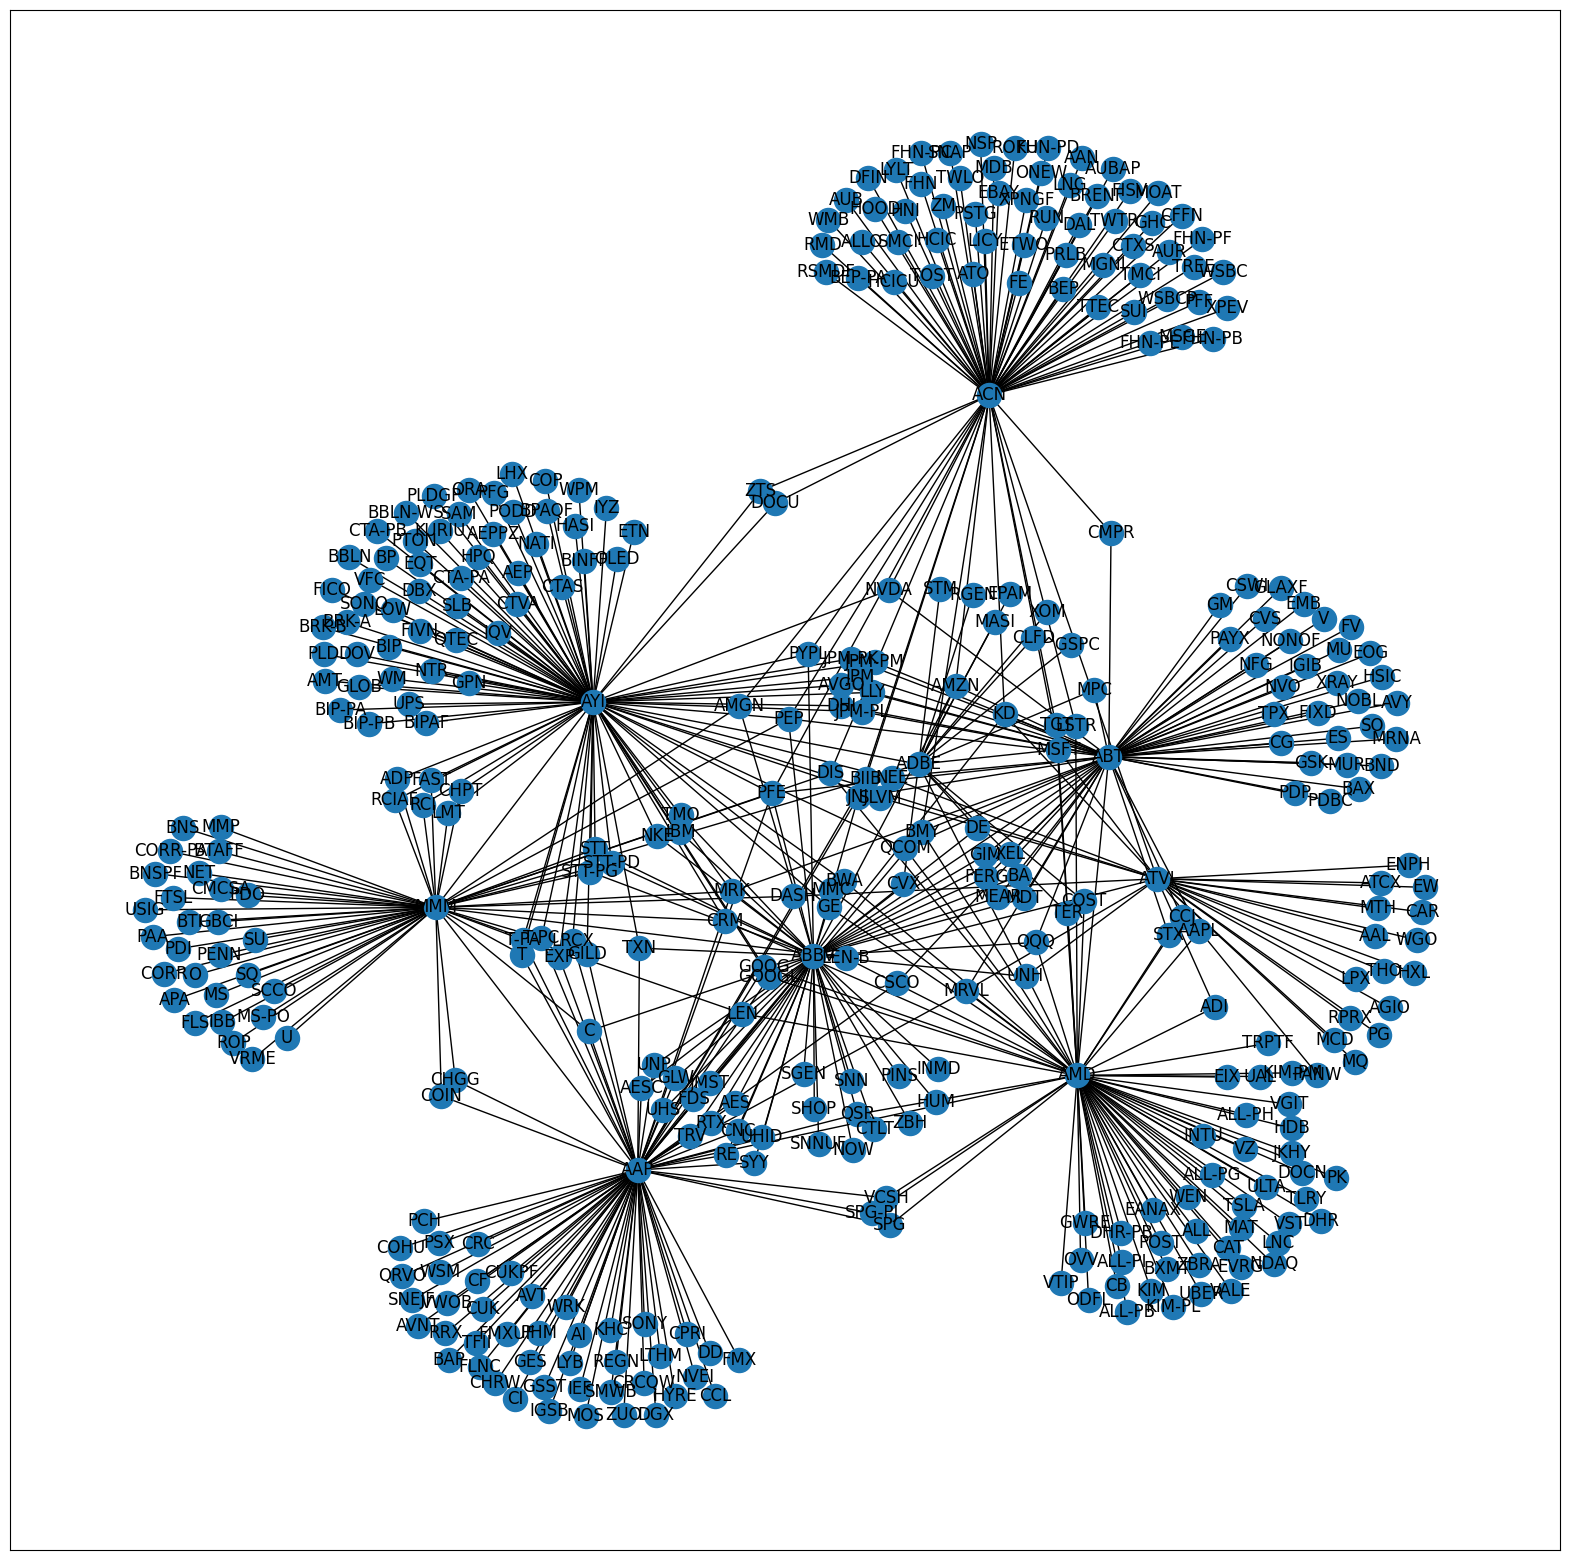

In [222]:
def printGraph(day = 'day0', full=True):
    G_of_day0 = nx.from_pandas_edgelist(edgesOfDays[day], source='Source',target='Target',edge_attr='weight')
    if not full:
        # remove all companies with degree = 1, but those companies in our sample list with degree 1 should be left. 
        remove = [node for node,degree in dict(G_of_day0.degree()).items() if (degree < 2 and node not in sample10)]
        G_of_day0.remove_nodes_from(remove)
    plt.figure(figsize=(20,20))
    nx.draw_networkx(G_of_day0)
    print("Nodes: ", len(G_of_day0.nodes))
    print('Edges: ', len(G_of_day0.edges))
    return G_of_day0
G_of_day0 = printGraph('day0', full=True)

Nodes:  104
Edges:  247
['MMM', 'ABT', 'ABBV', 'ACN', 'ATVI', 'AYI', 'ADBE', 'AMD', 'AAP', 'AES']


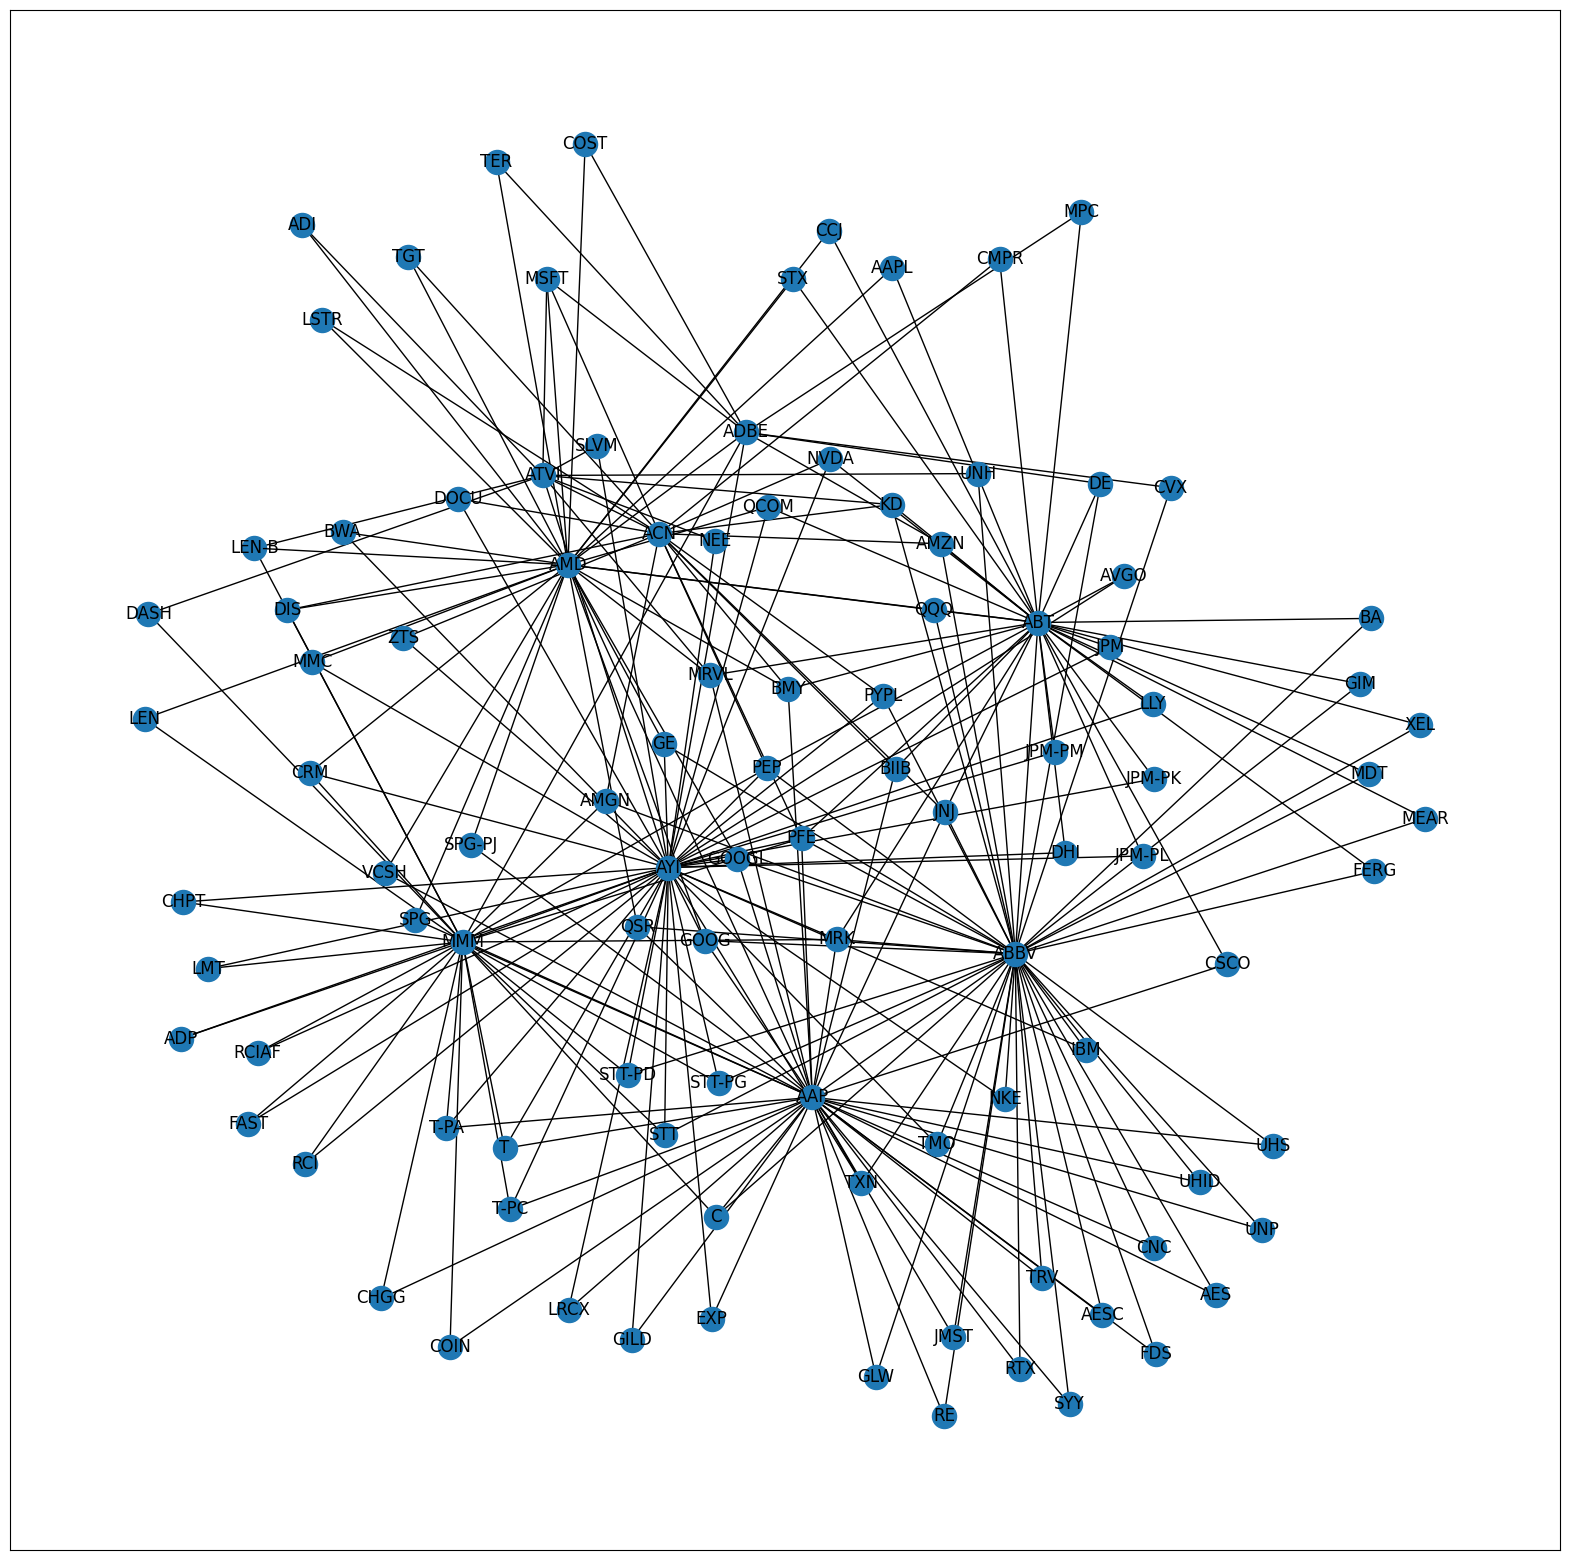

In [224]:
G_of_day0 = printGraph('day0', full=False)
print(sample10)

In [218]:
('ALB','KIM-PL') in G_of_day0.edges, ('AMD','KIM-PL') in G_of_day0.edges, ('ALB','AMD') in G_of_day0.edges

(True, True, False, True)

Nodes:  336
Edges:  429


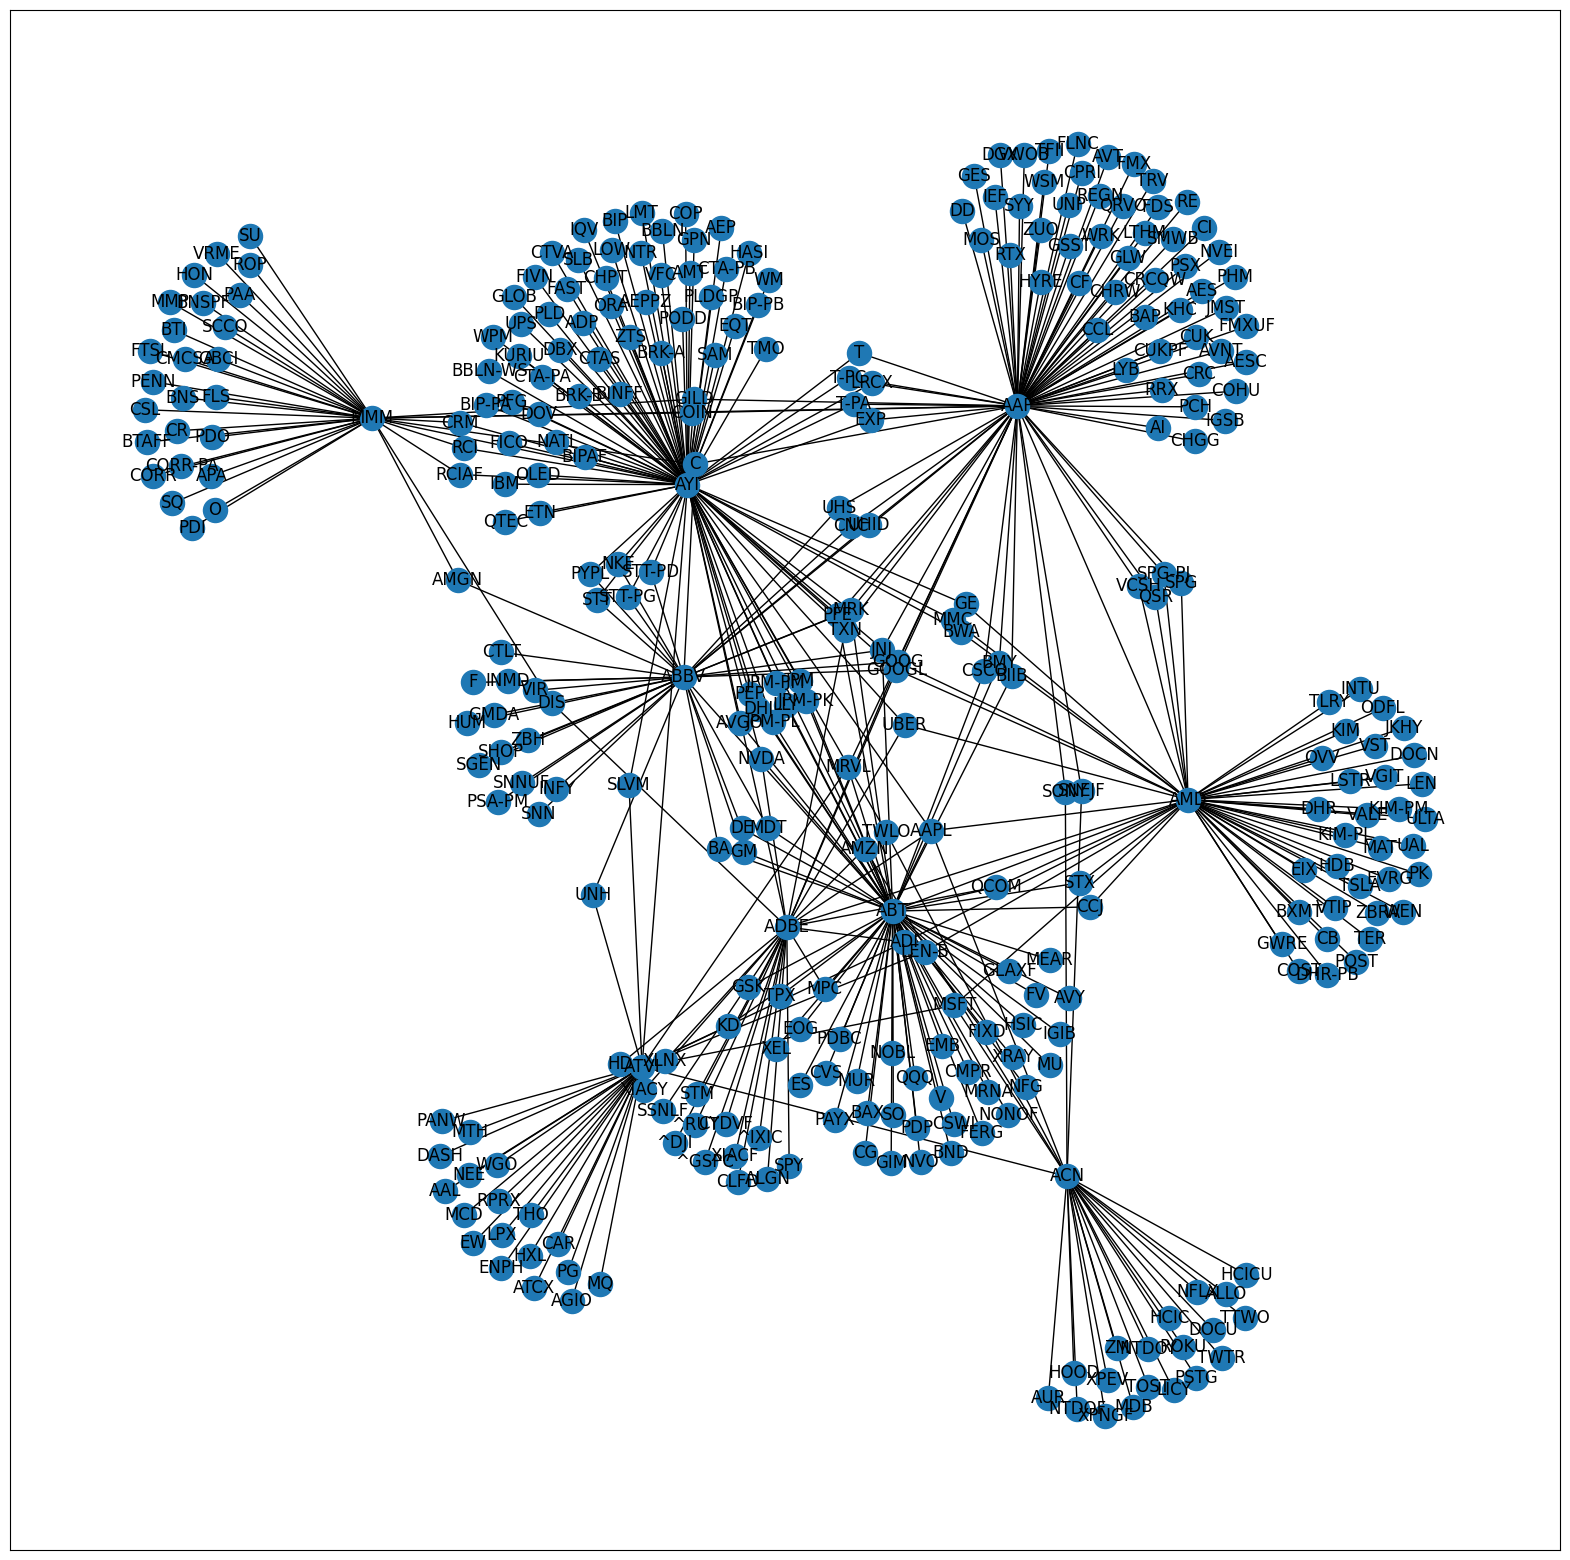

In [225]:
G_of_day1 = printGraph('day1', full=True)

Nodes:  77
Edges:  170


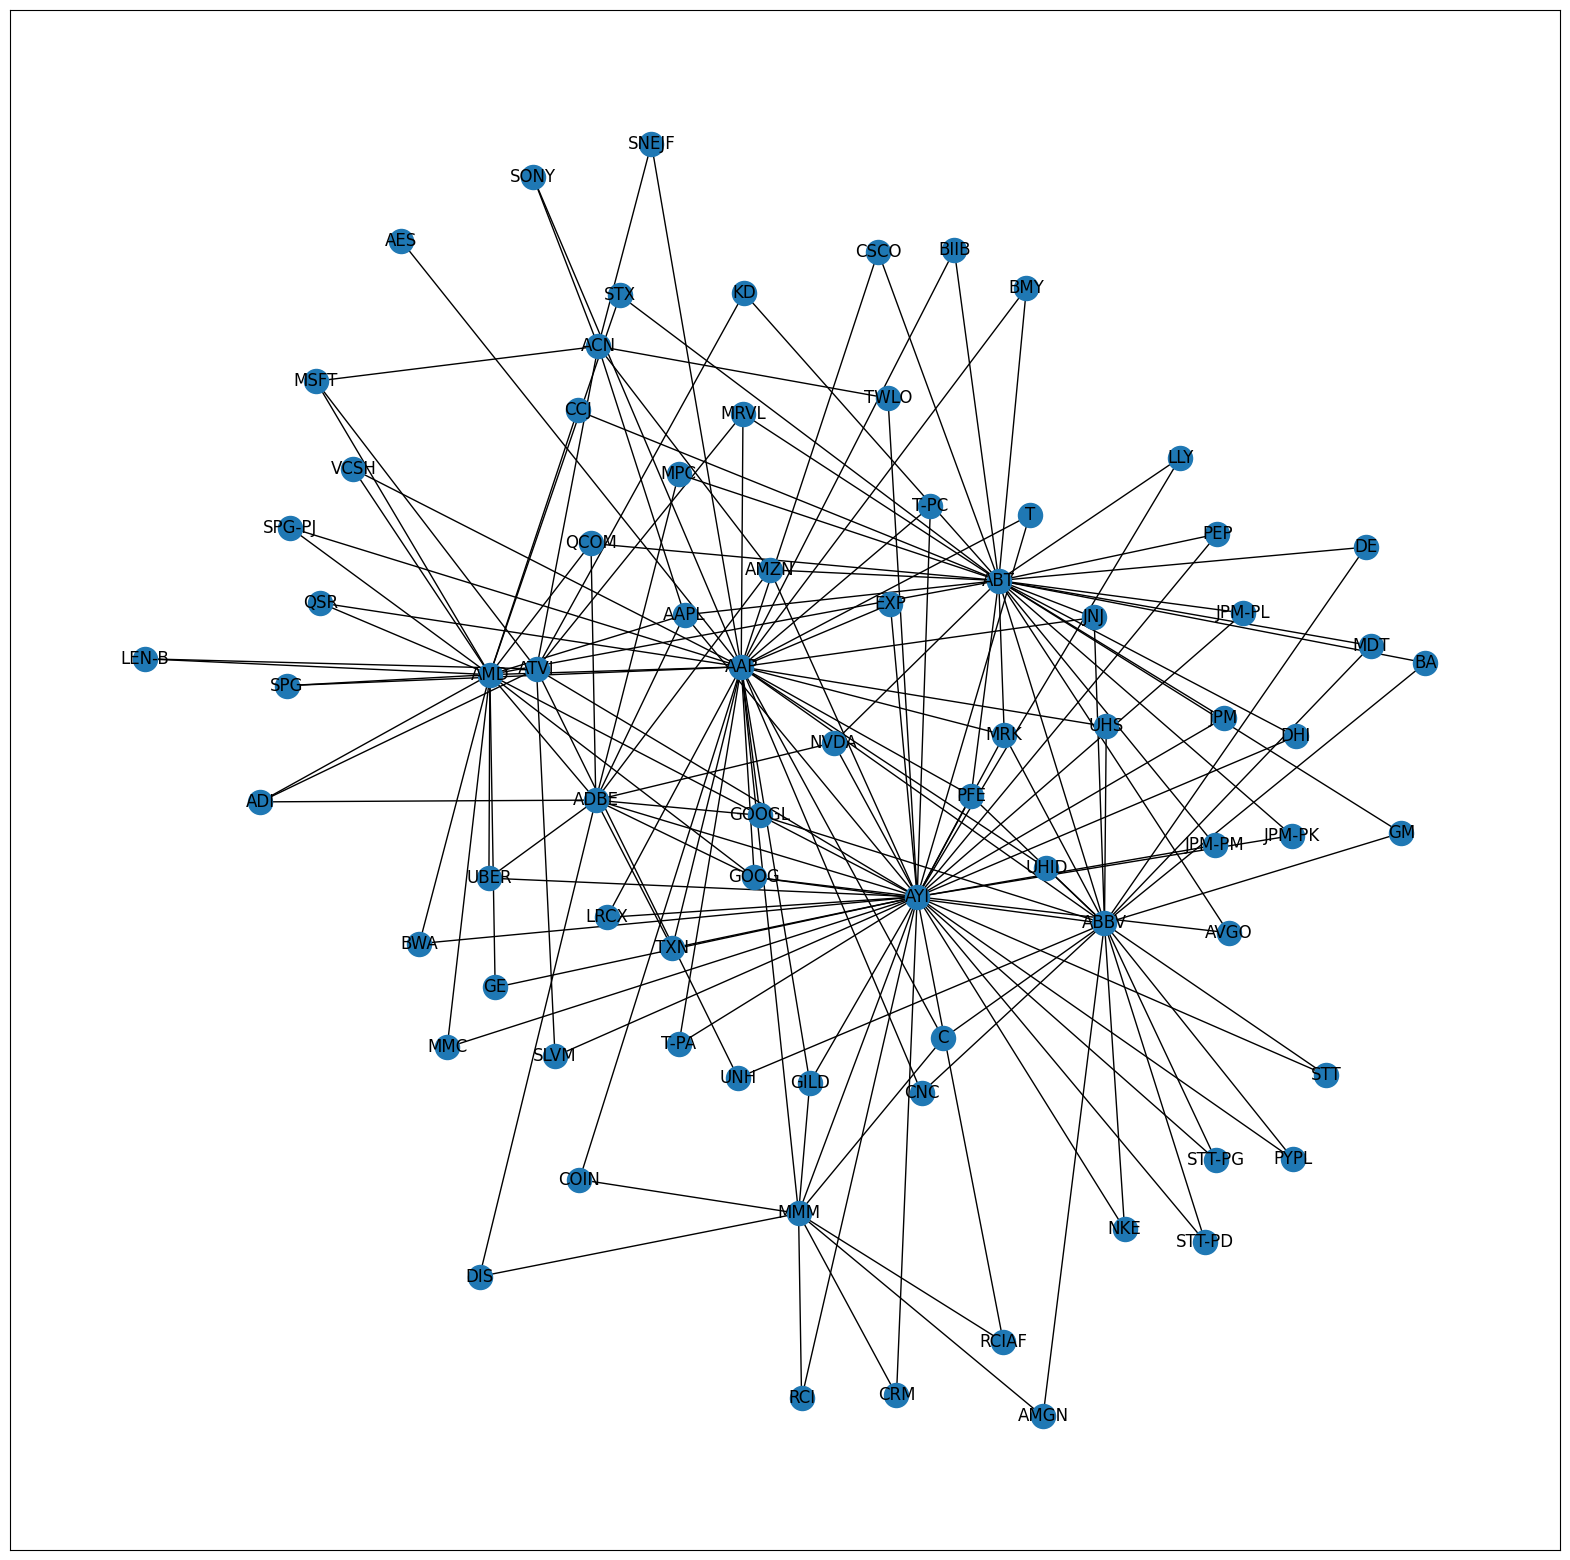

In [226]:
G_of_day1 = printGraph('day1', full=False)

In [199]:
# an example of a companies' news file. 1706 news, 8 news per day, 220 days
ABT_news = pd.read_csv(news_with_related_company+'ABT_news.csv')
ABT_news = ABT_news.iloc[112:]
ABT_news.head(20)

,Id,Company,Date,Title,Publisher,Link,ProviderPublishTime,Type,RelatedCompany
112,634972ba-aaa0-38d6-b807-7da8238de34f,ABT,2022-2-9,Daily Spotlight: Rates Ready to Rise,Argus Research,https://finance.yahoo.com/m/634972ba-aaa0-38d6...,1644390591,STORY,['ABT']
113,fcde14a7-b4c9-3ab9-b9a1-5708d057e32b,ABT,2022-2-9,UNIVEST FINANCIAL Corp Buys Technology Select ...,GuruFocus.com,https://finance.yahoo.com/news/univest-financi...,1644334701,STORY,"['SO', 'AVGO', 'BND', 'MDT', 'BMY', 'ABT', 'AV..."
114,909680a2-1260-333d-8e41-1f9b45612195,ABT,2022-2-9,High drug prices due to ‘complex health care s...,Yahoo Finance Video,https://finance.yahoo.com/video/high-drug-pric...,1644333024,VIDEO,"['NONOF', 'NVO', 'LLY', 'BIIB', 'MRNA', 'GLAXF..."
115,7e29a18f-0417-3292-9b30-9348011a7c35,ABT,2022-2-9,Affinity Wealth Management Llc Buys Fidelity T...,GuruFocus.com,https://finance.yahoo.com/news/affinity-wealth...,1644331102,STORY,"['CG', 'CCJ', 'ABT', 'EOG', 'PDBC', 'MPC', 'MU..."
116,dde57cf4-df98-3b06-85bb-73734d5e45a4,ABT,2022-2-9,"Karpas Strategies, Llc Buys General Motors Co,...",GuruFocus.com,https://finance.yahoo.com/news/karpas-strategi...,1644259108,STORY,"['CMPR', 'AAPL', 'NVDA', 'GM', 'DE', 'AMZN', '..."
117,f4ca68c1-77c3-308e-92fa-44d490e4fff5,ABT,2022-2-9,"Windsor Capital Management, LLC Buys Abbott La...",GuruFocus.com,https://finance.yahoo.com/news/windsor-capital...,1644259081,STORY,"['ABBV', 'XEL', 'FERG', 'PEP', 'ABT', 'MEAR', ..."
118,0afd7c02-368b-30a5-a0cc-5d72cdf49c95,ABT,2022-2-9,3 Medical Products Stocks Poised to Beat This ...,Zacks,https://finance.yahoo.com/news/3-medical-produ...,1644245342,STORY,"['HSIC', 'XRAY', 'BAX', 'ABT']"
119,6e3c75f8-27b3-35c1-9eb6-8255ef680af9,ABT,2022-2-9,"Stuart Chaussee & Associates, Inc. Buys ProSha...",GuruFocus.com,https://finance.yahoo.com/news/stuart-chaussee...,1644244694,STORY,"['QCOM', 'ABT', 'CVS', 'V', 'CSCO', 'NOBL', 'ES']"
120,634972ba-aaa0-38d6-b807-7da8238de34f,ABT,2022-2-10,Daily Spotlight: Rates Ready to Rise,Argus Research,https://finance.yahoo.com/m/634972ba-aaa0-38d6...,1644390591,STORY,['ABT']
121,fcde14a7-b4c9-3ab9-b9a1-5708d057e32b,ABT,2022-2-10,UNIVEST FINANCIAL Corp Buys Technology Select ...,GuruFocus.com,https://finance.yahoo.com/news/univest-financi...,1644334701,STORY,"['SO', 'AVGO', 'BND', 'MDT', 'BMY', 'ABT', 'AV..."


In [13]:
with open('../data/ADGAT_Data/x_numerical.pkl', 'rb') as handle:
    a = pickle.load(handle)
a.shape

(54125, 7)

In [25]:
import pandas as pd
HIG = pd.read_csv("/home/yingjie/Year_1/SP500_historical_data_download_yfinance/news_with_related_company/HIG_news.csv",
                  header=0, 
                  names=['Id','Company','Date','Title','Publisher','Link','ProviderPublishTime','Type','RelatedCompany', 'Text']
                  )
HIG


,Id,Company,Date,Title,Publisher,Link,ProviderPublishTime,Type,RelatedCompany,Text
0,235fdc26-86e2-3763-a2b0-f0f4153efa41,HIG,2022-9-20,Is The Hartford Financial Services Group (HIG)...,Zacks,https://finance.yahoo.com/news/hartford-financ...,1662990001,STORY,"['HIG-PG', 'ORI']",[The proven Zacks Rank system focuses on earni...
1,b17e24a1-3baf-3340-af12-ac5198dccb52,HIG,2022-9-20,"AON Forms STG to Better Serve Insurance, Reins...",Zacks,https://finance.yahoo.com/news/aon-forms-stg-b...,1662751747,STORY,"['AON', 'MTG', 'RDN', 'HIG-PG']",[Aon plc AON recently set up a Strategy and Te...
2,7e772bb9-80c7-3663-88e1-3fed720ff3b0,HIG,2022-9-20,The Hartford Expands Medical Provider Training...,Business Wire,https://finance.yahoo.com/news/hartford-expand...,1662728700,STORY,"['HIG', 'HIG-PG']",[Insurer extends partnership with Yale School ...
3,6079b692-5ac5-324b-8691-7317f252d478,HIG,2022-9-20,The Hartford Announces Doug Elliot To Retire A...,Business Wire,https://finance.yahoo.com/news/hartford-announ...,1662547800,STORY,"['HIG', 'HIG-PG']","[HARTFORD, Conn., September 07, 2022--(BUSINES..."
4,16c83937-c31b-3cd0-8b17-5c4ef18a3f32,HIG,2022-9-20,Are You Looking for a High-Growth Dividend Stock?,Zacks,https://finance.yahoo.com/news/looking-high-gr...,1662392703,STORY,"['HIG', 'HIG-PG']",[All investors love getting big returns from t...
...,...,...,...,...,...,...,...,...,...,...
1258,3edee36c-ecb7-3b74-8356-b05bebe2cb69,HIG,2023-2-26,"Zacks Industry Outlook Highlights MetLife, Ame...",Zacks,https://finance.yahoo.com/news/zacks-industry-...,1675770011,STORY,"['ORI', 'PRU', 'MET', 'AIG', 'MET-PE', '^GSPC'...","[For Immediate ReleaseChicago, IL – February 7..."
1259,971b087a-2545-3643-af20-ad7e51689abc,HIG,2023-2-26,5 Stocks to Watch From the Prospering Multilin...,Zacks,https://finance.yahoo.com/news/5-stocks-watch-...,1675697703,STORY,"['AIG', '^GSPC', 'PRU', 'MET-PE', 'HIG-PG', 'O...",[Product diversification helps Zacks Multiline...
1260,44f3e596-f7fb-3277-85cf-b807268d34e9,HIG,2023-2-26,"The Hartford Financial Services Group, Inc. (N...",Insider Monkey,https://finance.yahoo.com/news/hartford-financ...,1675667201,STORY,"['HIG', 'HIG-PG']","[The Hartford Financial Services Group, Inc. (..."
1261,275473b0-a8b2-3912-8f10-bcacb672da78,HIG,2023-2-26,Hartford Financial (HIG) Q4 Earnings Beat on P...,Zacks,https://finance.yahoo.com/news/hartford-financ...,1675446725,STORY,"['HIG', 'HIG-PG', 'PGR']","[The Hartford Financial Services Group, Inc. H..."


In [26]:
print(HIG.iloc[0]['Title'])
print(HIG.iloc[0]['RelatedCompany'])
print(HIG.iloc[0]['Text'])

Is The Hartford Financial Services Group (HIG) a Great Value Stock Right Now?
['HIG-PG', 'ORI']
[The proven Zacks Rank system focuses on earnings estimates and estimate revisions to find winning stocks. Nevertheless, we know that our readers all have their own perspectives, so we are always looking at the latest trends in value, growth, and momentum to find strong picks.Considering these trends, value investing is clearly one of the most preferred ways to find strong stocks in any type of market. Value investors use a variety of methods, including tried-and-true valuation metrics, to find these stocks.Luckily, Zacks has developed its own Style Scores system in an effort to find stocks with specific traits. Value investors will be interested in the system's "Value" category. Stocks with both "A" grades in the Value category and high Zacks Ranks are among the strongest value stocks on the market right now.The Hartford Financial Services Group (HIG) is a stock many investors are watching 

# Dataset Visualization

In [2]:
from Generate_dataset import MyDataset

# ERGATFOLDERPATH = '/home/yingjie/Year_1/ERGAT/'
ERGATFOLDERPATH = '/home/yingjie_niu/Year_2/ERGAT-master/'


In [3]:
def VisualizeGraphDataset(dataset, day = 0, full=True):
    """
    Input:
    "dataset" : graph dataset loaded using MyDataset class
    "day" : the index of day of which we want to visualize
    "full" : whethere or not print the whole graph. "True" for whole graph, "False" for removing nodes whoes degree<2
    """
    PERIOD_START = '202209'
    PERIOD_END = '202310'
    folder_path =f'{ERGATFOLDERPATH}data/SP500/dataset{PERIOD_START}-{PERIOD_END}/'
    quantitative_fileList = listdir(folder_path+'quantitative_'+PERIOD_START+'_'+PERIOD_END)
    company_list = np.load(folder_path + 'company_list.npy')
    Node_Idx_To_Comp = []
    for company in company_list:
        if company+'.csv' in quantitative_fileList:
            Node_Idx_To_Comp.append(company)
        else:
            print(company,'.csv not exist!')
    edges = {
        "Source":[Node_Idx_To_Comp[idx] for idx in list(np.array(dataset[day].edge_index[0]))],
        'Target':[Node_Idx_To_Comp[idx] for idx in list(np.array(dataset[day].edge_index[1]))],
        'Weight':list(np.array(dataset[day].edge_attr).reshape(-1))
    }
    G_of_day = nx.from_pandas_edgelist(edges, source='Source',target='Target',edge_attr='Weight')
    if not full:
        # remove all companies with degree = 1, but those companies in our sample list with degree 1 should be left. 
        remove = [node for node,degree in G_of_day.degree() if (degree < 2 and node in company_list)]   
        G_of_day.remove_nodes_from(remove)
    temp =list(G_of_day.degree())
    temp.sort(key=lambda x:x[1], reverse=True)
    print(temp)

    plt.figure(figsize=(20,20))
    nx.draw_networkx(G_of_day)
    print("Dataset path: ",dataset.processed_dir)
    fileList = listdir(dataset.processed_dir)
    fileList.sort()
    print('Date: ',fileList[day])
    print('Graph Metadata: ', dataset[day])
    print(f"All Nodes: {dataset[day].x.shape[0]} Connected Nodes: {len(G_of_day.nodes)} (" + '%.4g'%(len(G_of_day.nodes)/dataset[day].x.shape[0]*100) + f"%) Edges: {len(G_of_day.edges)} ") 
    return G_of_day

def Describe(G_of_day):
    return pd.DataFrame(G_of_day.degree(), columns=['Node','Degree']).describe()

## (Wrong) WrongWeight_NoLookBack_merge/ Node3_Edge1_Normmean_Threshold1.0_WeightedEdgeCounter_merge_True
* Node features = 3
* Edge features = 1
* Mean normalize node features and edge weights. 
* Threshold = 1.0, 如果两个公司在同一天内同时出现在一篇新闻中的次数大于threshold，则给这两个公司node建一个edge
* WeightedEdge = Counter, edge weight是两个公司共同出现的次数（对每天的图中所有edge weight 做normalize）
* build_edges = merge， 每天的图会叠加在之前的图上，构造出一个historical graph
* forRNN = True: Node embedding should be (LOOKBACK_WINDOW, node_features)

由于Generate_dataset.py的一个bug，这个数据集的edge weights是错的，但是edge是正确的，edge的建立方法为不考虑LOOKBACK WINDOW的merge， 即

* Day1: G1 = g1
* Day2: G2 = G1 + g2
* Day3: G3 = G1 + G2 + g3
* ...
* Day13: G13 = G1 + G2 + ... + G12 + g13
* Day14: G14 = G2 + G3 + ... + G13 + g14

这个数据集最后一天的图即为整个period内所有daily graph整合起来的结果

In [4]:
dataset = MyDataset(root=f'{ERGATFOLDERPATH}data/202209_202310/dynamic/Node3_Edge1_Normmean_Threshold1.0_WeightedEdgeCounter_merge_True/')

In [5]:
dataset[0],dataset[1],dataset[2],dataset[3],dataset[4],dataset[5],dataset[6],dataset[7], dataset[13],dataset[14],dataset[15]

(Data(x=[431, 13, 3], edge_index=[2, 412], edge_attr=[412, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 530], edge_attr=[530, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 664], edge_attr=[664, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 694], edge_attr=[694, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 742], edge_attr=[742, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 782], edge_attr=[782, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 864], edge_attr=[864, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 948], edge_attr=[948, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 1320], edge_attr=[1320, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 1378], edge_attr=[1378, 1], y=[431, 1]),
 Data(x=[431, 13, 3], edge_index=[2, 1440], edge_attr=[1440, 1], y=[431, 1]))

In [6]:
dataset[0].edge_attr.dtype, dataset[0].edge_index.dtype, dataset[0].x.shape[0], dataset[0].y.dtype, dataset[0].is_undirected()

(torch.float64, torch.int64, 431, torch.float64, True)

[('NAVI', 19), ('AAPL', 8), ('QCOM', 6), ('AVGO', 5), ('TXT', 5), ('NI', 5), ('VRTX', 5), ('CAG', 5), ('MCK', 5), ('KIM', 4), ('F', 4), ('TGT', 4), ('FDX', 4), ('NKE', 4), ('KO', 4), ('DAL', 4), ('UAL', 4), ('LUV', 4), ('SYY', 4), ('GIS', 4), ('AAL', 4), ('MSFT', 4), ('ALK', 4), ('CNC', 4), ('DIS', 3), ('OXY', 3), ('HES', 3), ('BAC', 3), ('ADI', 3), ('STT', 3), ('GS', 3), ('MA', 3), ('MRK', 3), ('UPS', 3), ('MCD', 3), ('LMT', 3), ('NOC', 3), ('BA', 3), ('O', 3), ('FE', 3), ('XEL', 3), ('PNW', 3), ('LNT', 3), ('K', 3), ('TXN', 3), ('C', 3), ('CCI', 3), ('AMD', 3), ('SWKS', 3), ('VFC', 3), ('MKC', 3), ('MAT', 2), ('HAS', 2), ('MPC', 2), ('NTAP', 2), ('FRT', 2), ('SPG', 2), ('JPM', 2), ('HD', 2), ('GPN', 2), ('V', 2), ('OMC', 2), ('AMG', 2), ('BEN', 2), ('GOOGL', 2), ('MS', 2), ('AEE', 2), ('DUK', 2), ('CNP', 2), ('UAA', 2), ('UA', 2), ('DHI', 2), ('CVS', 2), ('SBAC', 2), ('AMT', 2), ('CPB', 2), ('RCL', 2), ('INTC', 2), ('SJM', 2), ('CVX', 2), ('AON', 2), ('AJG', 2), ('MMC', 2), ('NVDA', 

,Degree
count,209.000000
mean,1.971292
std,1.683957
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,19.000000


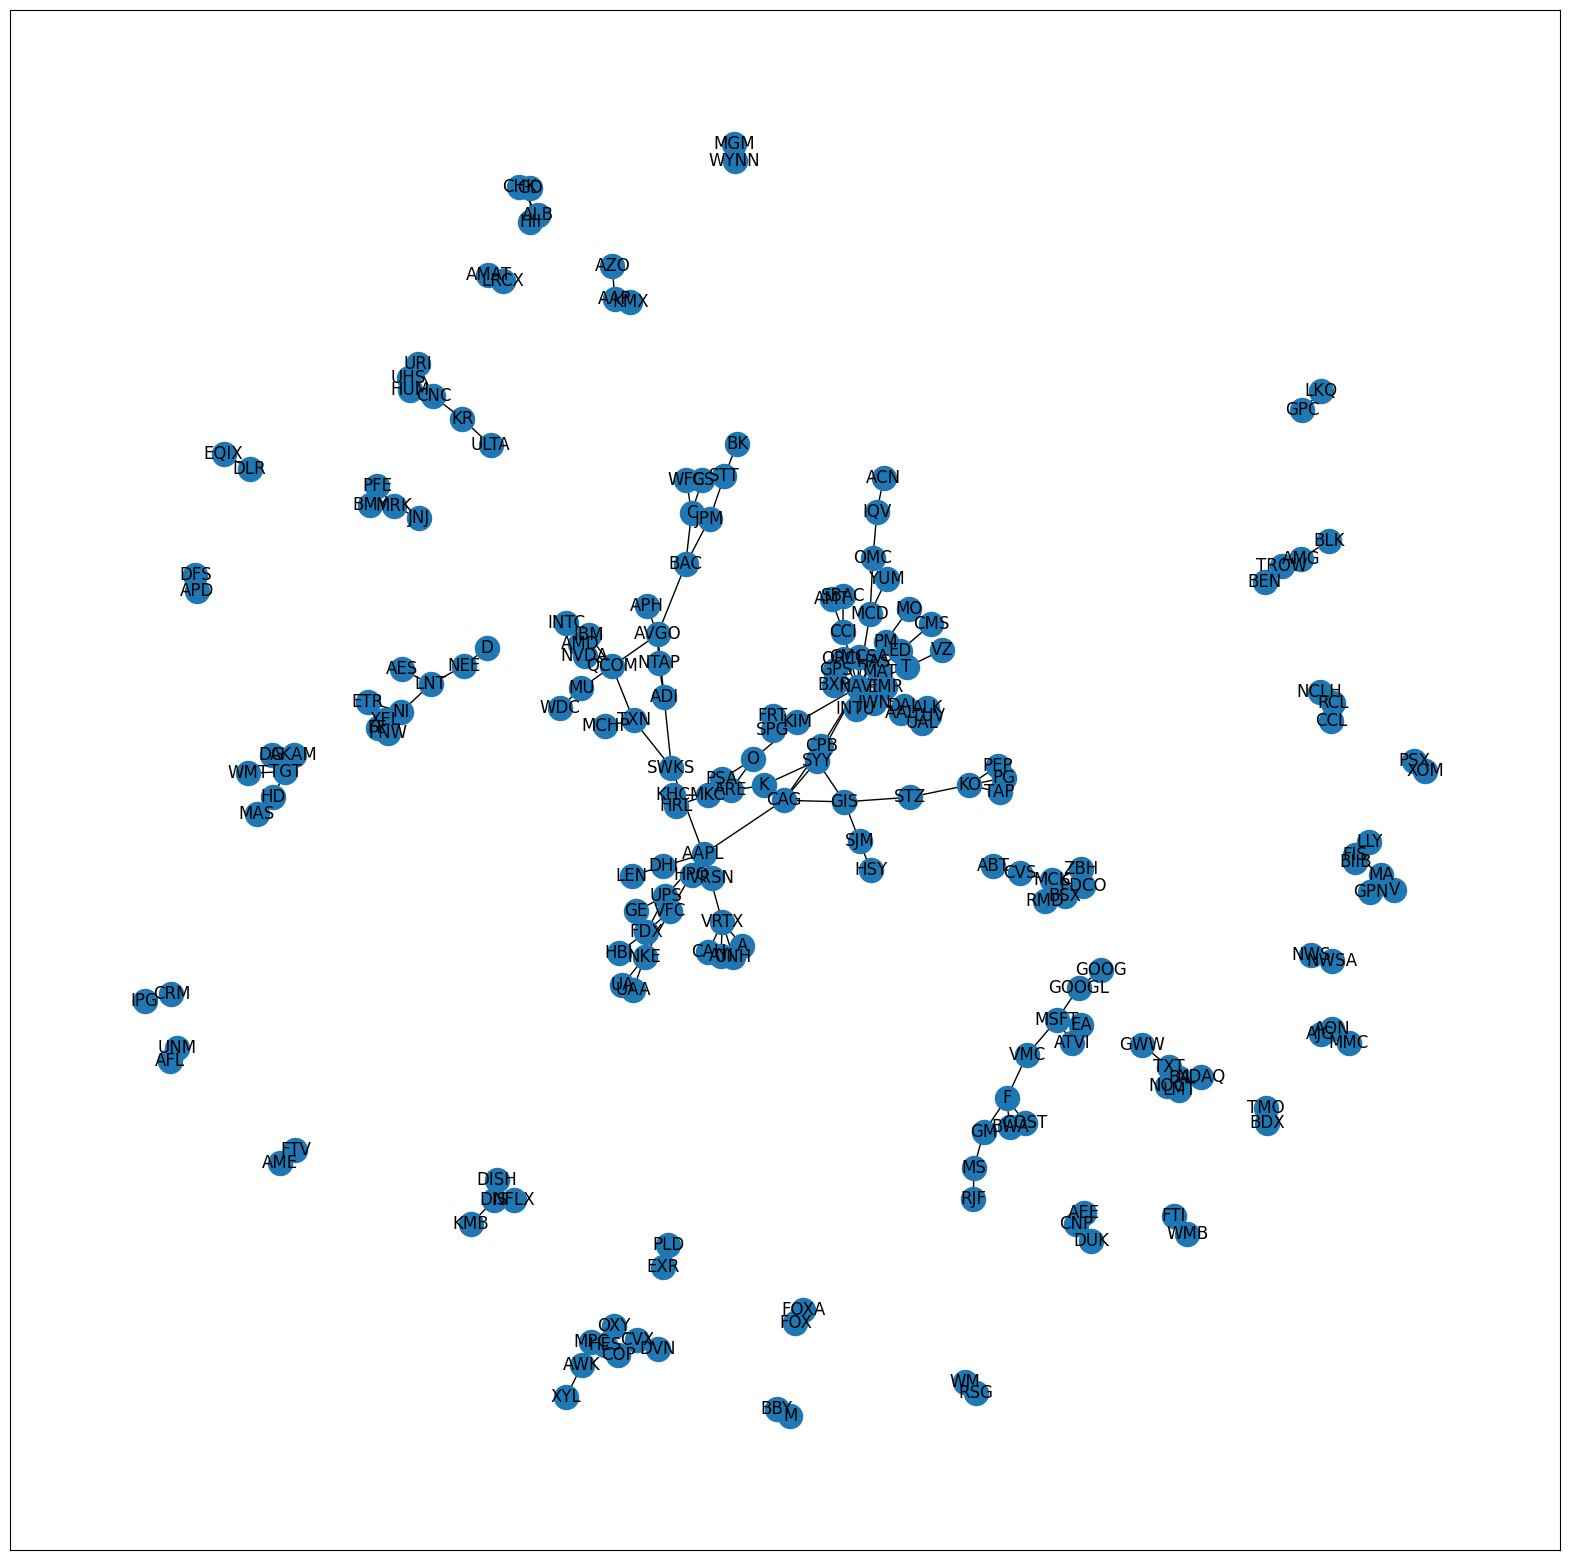

In [7]:
G_of_day = VisualizeGraphDataset(dataset, day=0, full=True)
Describe(G_of_day)

[('NAVI', 19), ('AAPL', 13), ('XOM', 9), ('QCOM', 6), ('F', 6), ('CAG', 6), ('VRTX', 6), ('AMD', 6), ('MCK', 6), ('OXY', 5), ('AVGO', 5), ('PFE', 5), ('TXT', 5), ('TGT', 5), ('NI', 5), ('MS', 5), ('UNH', 5), ('NVDA', 5), ('AAL', 5), ('MSFT', 5), ('MU', 5), ('KIM', 4), ('GS', 4), ('MRK', 4), ('FDX', 4), ('NOC', 4), ('BA', 4), ('O', 4), ('KO', 4), ('DAL', 4), ('UAL', 4), ('LUV', 4), ('SYY', 4), ('GIS', 4), ('NKE', 4), ('BIIB', 4), ('INTC', 4), ('ALK', 4), ('CNC', 4), ('CSCO', 4), ('UNP', 4), ('AMZN', 4), ('PNC', 4), ('DISH', 3), ('DIS', 3), ('HES', 3), ('BAC', 3), ('ADI', 3), ('STT', 3), ('MA', 3), ('UPS', 3), ('MCD', 3), ('LMT', 3), ('GOOGL', 3), ('FE', 3), ('XEL', 3), ('PNW', 3), ('LNT', 3), ('K', 3), ('TXN', 3), ('AEE', 3), ('AMT', 3), ('CCI', 3), ('SJM', 3), ('NEE', 3), ('HUM', 3), ('CVX', 3), ('SWKS', 3), ('VFC', 3), ('IBM', 3), ('C', 3), ('JNJ', 3), ('MKC', 3), ('MAT', 2), ('HAS', 2), ('MPC', 2), ('NTAP', 2), ('FRT', 2), ('SPG', 2), ('JPM', 2), ('GPN', 2), ('V', 2), ('OMC', 2), ('A

,Degree
count,232.000000
mean,2.284483
std,1.935345
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,19.000000


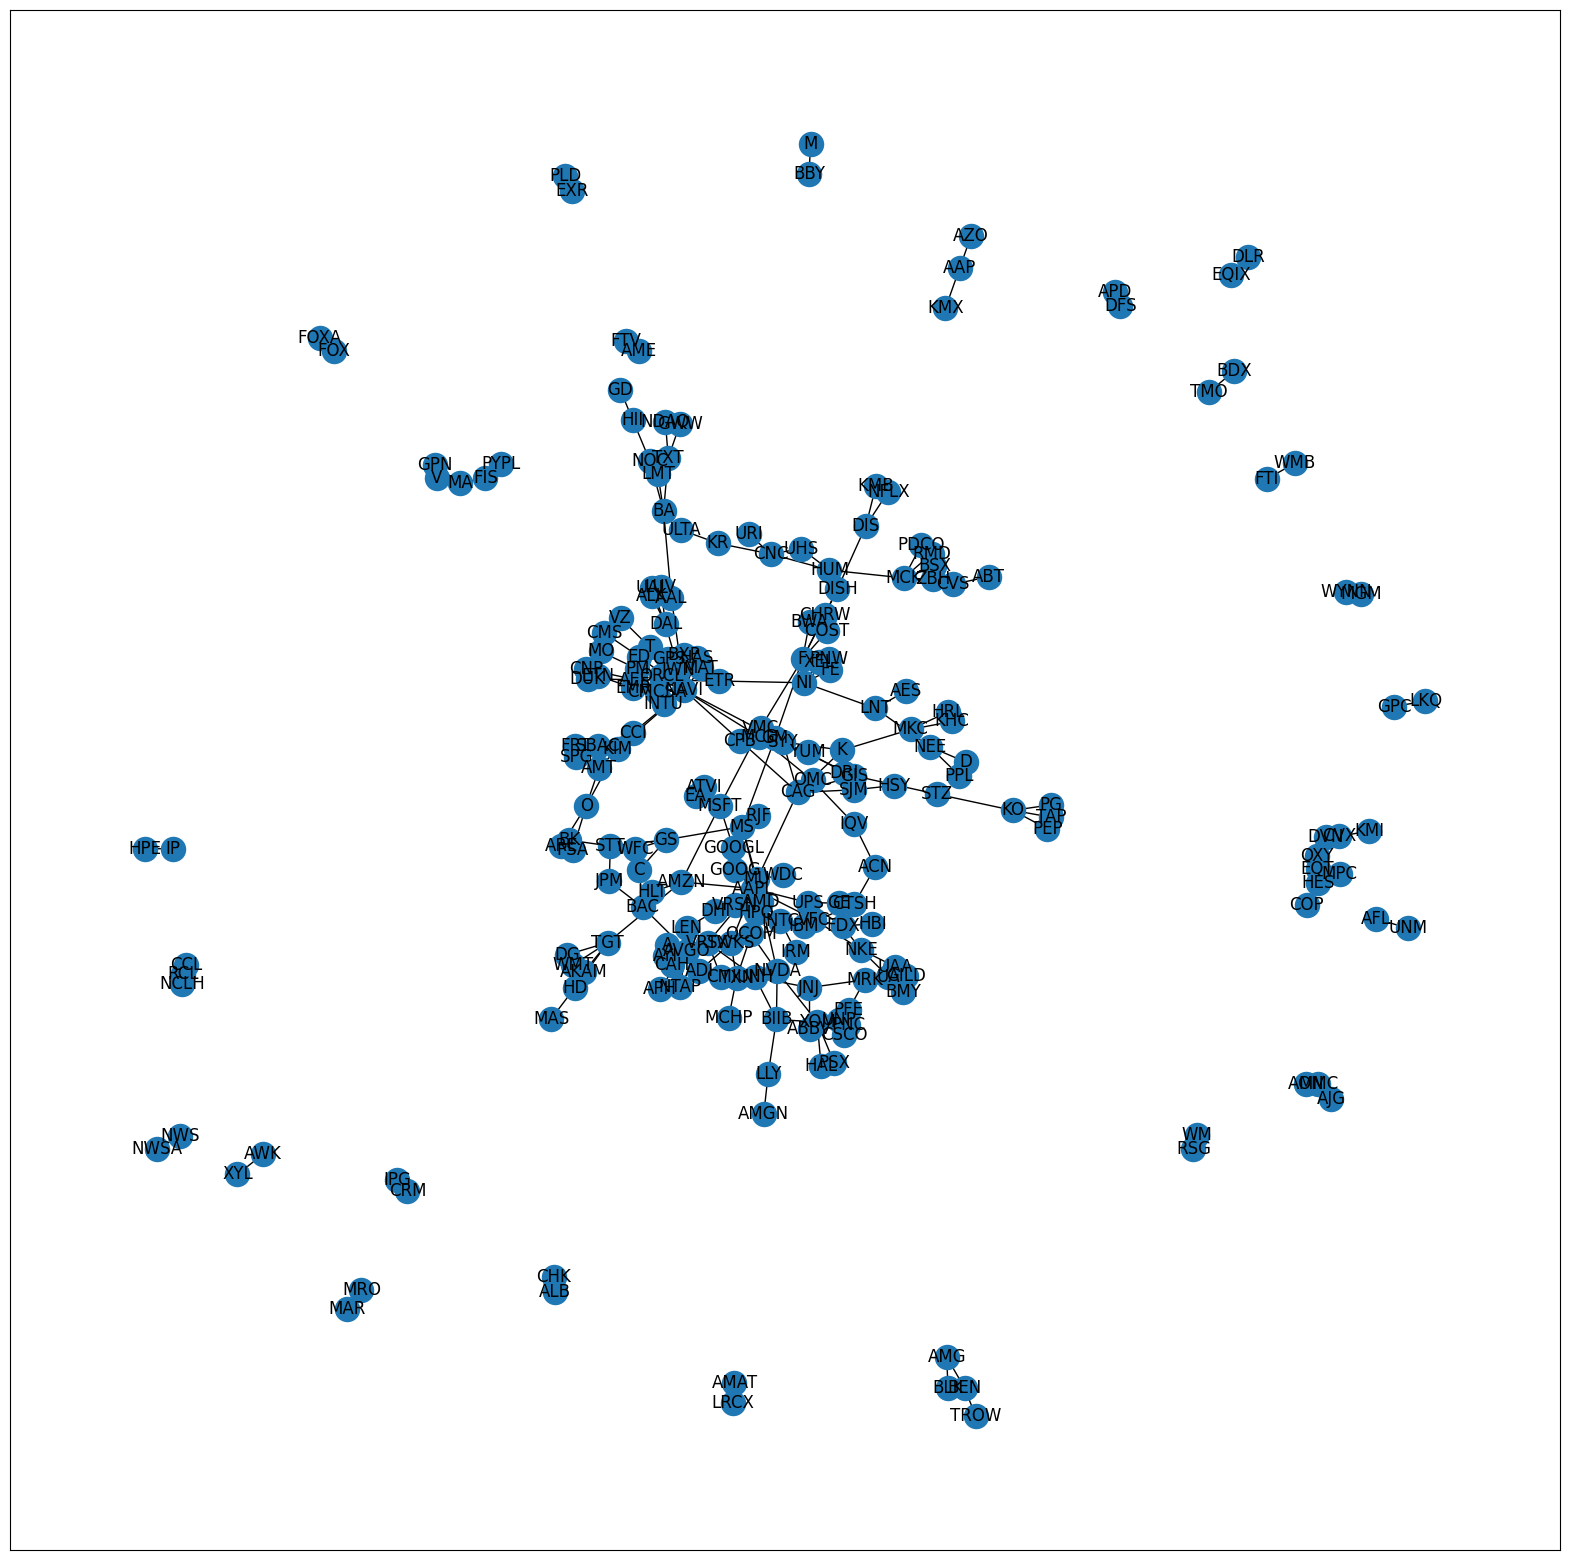

In [8]:
G_of_day = VisualizeGraphDataset(dataset, day=1, full=True)
Describe(G_of_day)

[('MSFT', 125), ('NVDA', 120), ('AMZN', 118), ('AAPL', 116), ('GOOGL', 96), ('TGT', 95), ('CVX', 93), ('WMT', 91), ('JNJ', 91), ('XOM', 88), ('KO', 86), ('CAT', 81), ('BAC', 75), ('PG', 74), ('DIS', 71), ('INTC', 68), ('HD', 67), ('ORCL', 67), ('NKE', 66), ('PEP', 64), ('CSCO', 64), ('UNH', 64), ('AMD', 63), ('NEE', 63), ('ABBV', 62), ('NFLX', 61), ('CRM', 60), ('V', 60), ('VZ', 59), ('COST', 58), ('MRK', 57), ('PFE', 57), ('BA', 56), ('IBM', 56), ('JPM', 53), ('MCD', 53), ('AXP', 51), ('CAH', 51), ('AVGO', 51), ('ABT', 50), ('GS', 49), ('F', 48), ('MA', 48), ('MCK', 47), ('LLY', 47), ('TXN', 47), ('ADM', 47), ('LMT', 46), ('ADBE', 46), ('DE', 46), ('OXY', 45), ('SBUX', 45), ('FDX', 45), ('T', 44), ('A', 44), ('WBA', 44), ('MMM', 44), ('USB', 43), ('KR', 43), ('UPS', 42), ('CVS', 41), ('LOW', 40), ('COP', 40), ('D', 39), ('AMAT', 38), ('HON', 38), ('GE', 37), ('PYPL', 37), ('CMG', 37), ('GIS', 36), ('MDT', 36), ('AMGN', 36), ('INTU', 36), ('DAL', 35), ('QCOM', 35), ('DG', 34), ('PM', 3

,Degree
count,424.000000
mean,21.334906
std,20.836777
min,1.000000
25%,8.000000
50%,14.000000
75%,27.000000
max,125.000000


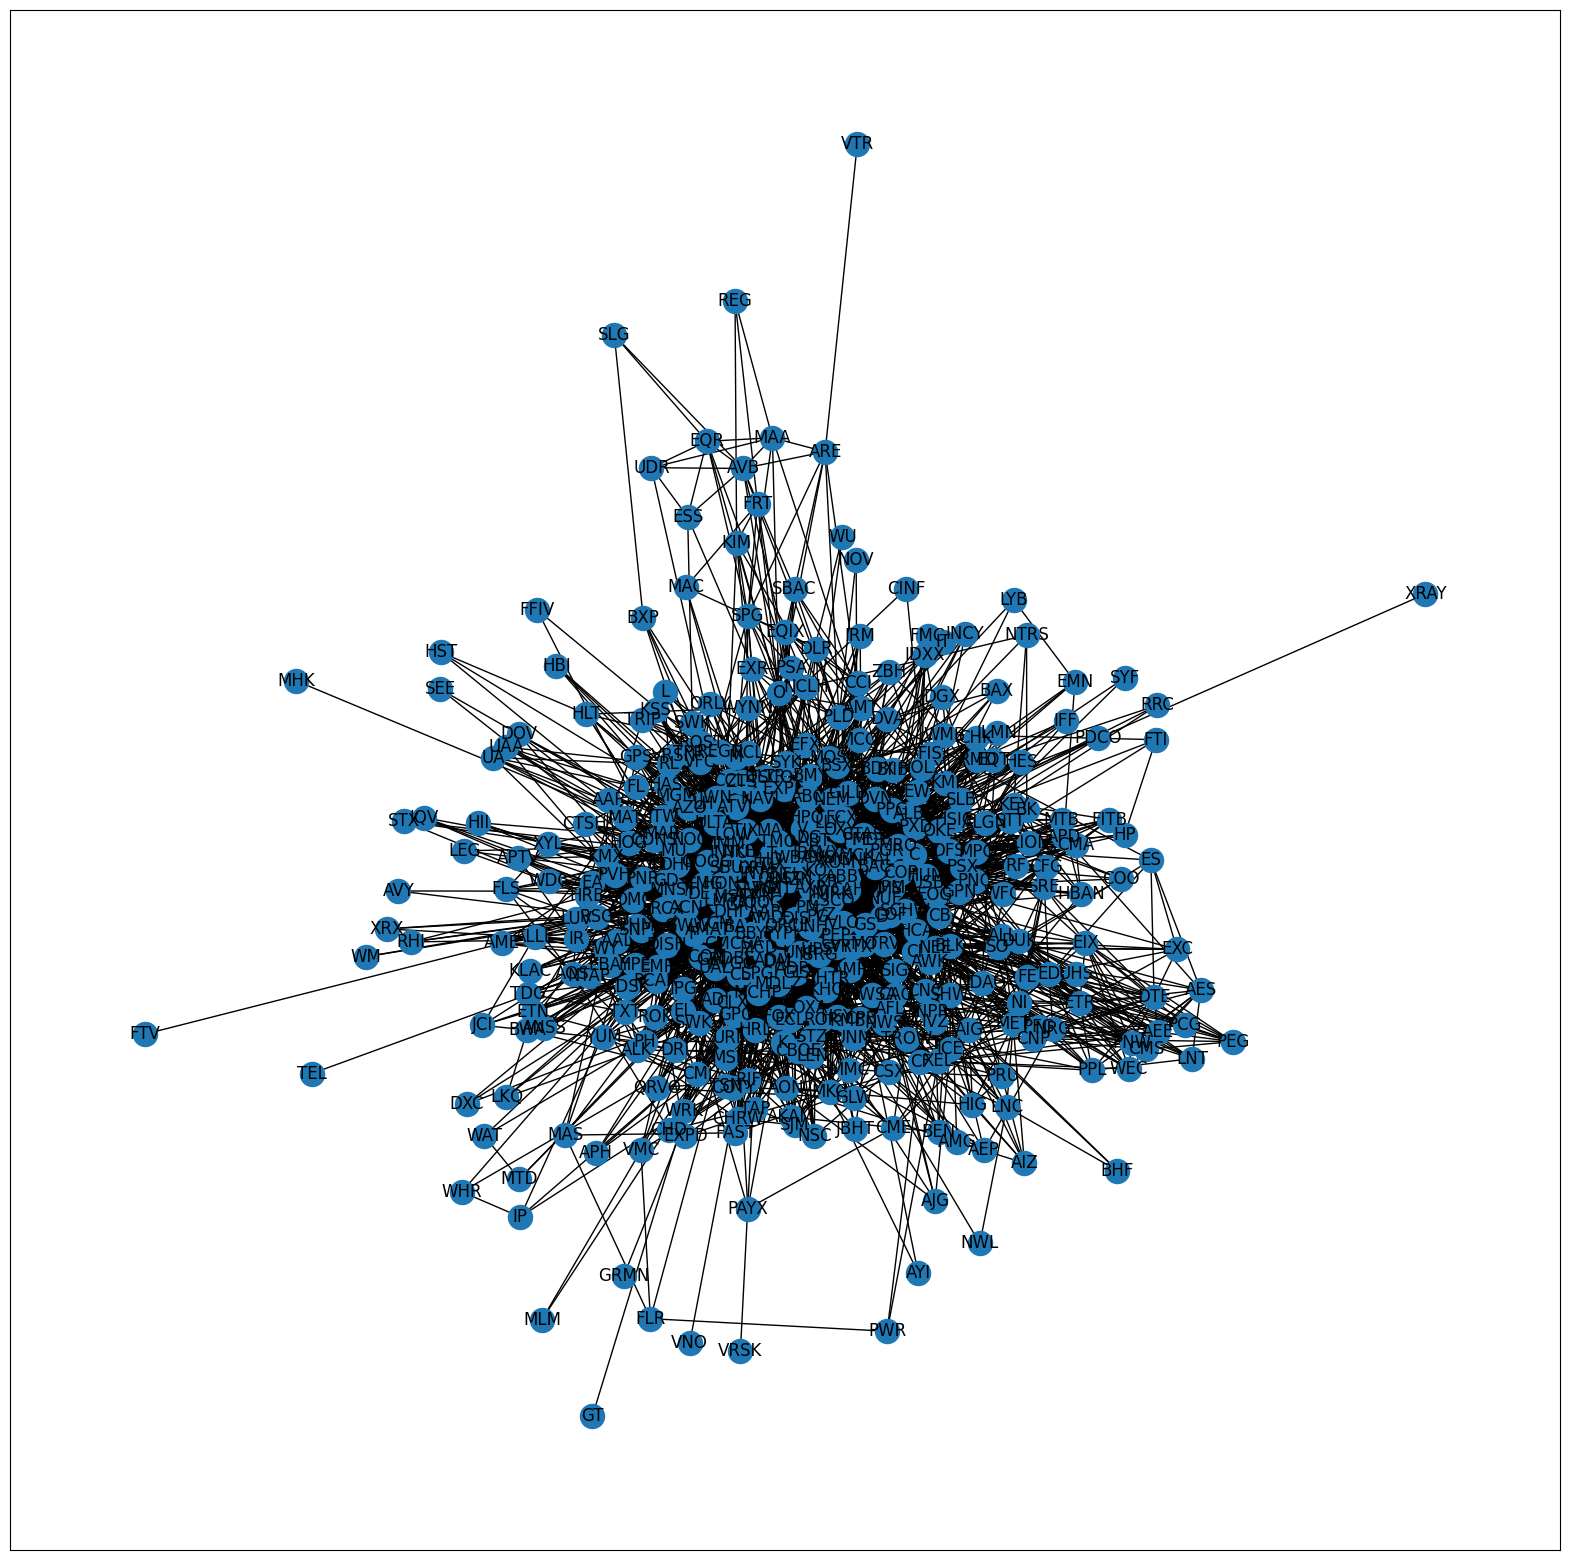

In [9]:
G_of_day = VisualizeGraphDataset(dataset, day=257, full=True)
Describe(G_of_day)

## (Wrong) WrongWeight_NoLookBack_merge/ Node3_Edge1_Normmean_Threshold2.0_WeightedEdgeCounter_merge_True


In [10]:
dataset = MyDataset(root=f'{ERGATFOLDERPATH}data/202209_202310/dynamic/Node3_Edge1_Normmean_Threshold2.0_WeightedEdgeCounter_merge_True/')

[('TXT', 3), ('UAL', 3), ('KO', 3), ('VFC', 3), ('AMG', 2), ('LMT', 2), ('NOC', 2), ('DAL', 2), ('TXN', 2), ('AAPL', 2), ('ALK', 2), ('LUV', 2), ('MCK', 2), ('F', 2), ('UHS', 2), ('MAT', 1), ('HAS', 1), ('DISH', 1), ('DIS', 1), ('NWS', 1), ('NWSA', 1), ('AVGO', 1), ('ADI', 1), ('FRT', 1), ('SPG', 1), ('GPN', 1), ('MA', 1), ('BEN', 1), ('BLK', 1), ('EXR', 1), ('PLD', 1), ('HES', 1), ('OXY', 1), ('GOOG', 1), ('GOOGL', 1), ('SYY', 1), ('K', 1), ('QCOM', 1), ('AES', 1), ('LNT', 1), ('CAH', 1), ('VRTX', 1), ('UAA', 1), ('UA', 1), ('WMT', 1), ('TGT', 1), ('BA', 1), ('SJM', 1), ('HSY', 1), ('AAL', 1), ('HPQ', 1), ('MCHP', 1), ('PM', 1), ('MO', 1), ('RCL', 1), ('NCLH', 1), ('PG', 1), ('FOX', 1), ('FOXA', 1), ('ATVI', 1), ('MSFT', 1), ('ZBH', 1), ('BBY', 1), ('M', 1), ('WYNN', 1), ('MGM', 1), ('PDCO', 1), ('NKE', 1), ('FDX', 1), ('TAP', 1), ('PEP', 1), ('HII', 1), ('GD', 1), ('COST', 1), ('HUM', 1), ('CNC', 1), ('WFC', 1), ('GS', 1), ('GM', 1)]
Dataset path:  /home/yingjie/Year_1/ERGAT/data/202

,Degree
count,79.000000
mean,1.240506
std,0.536255
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


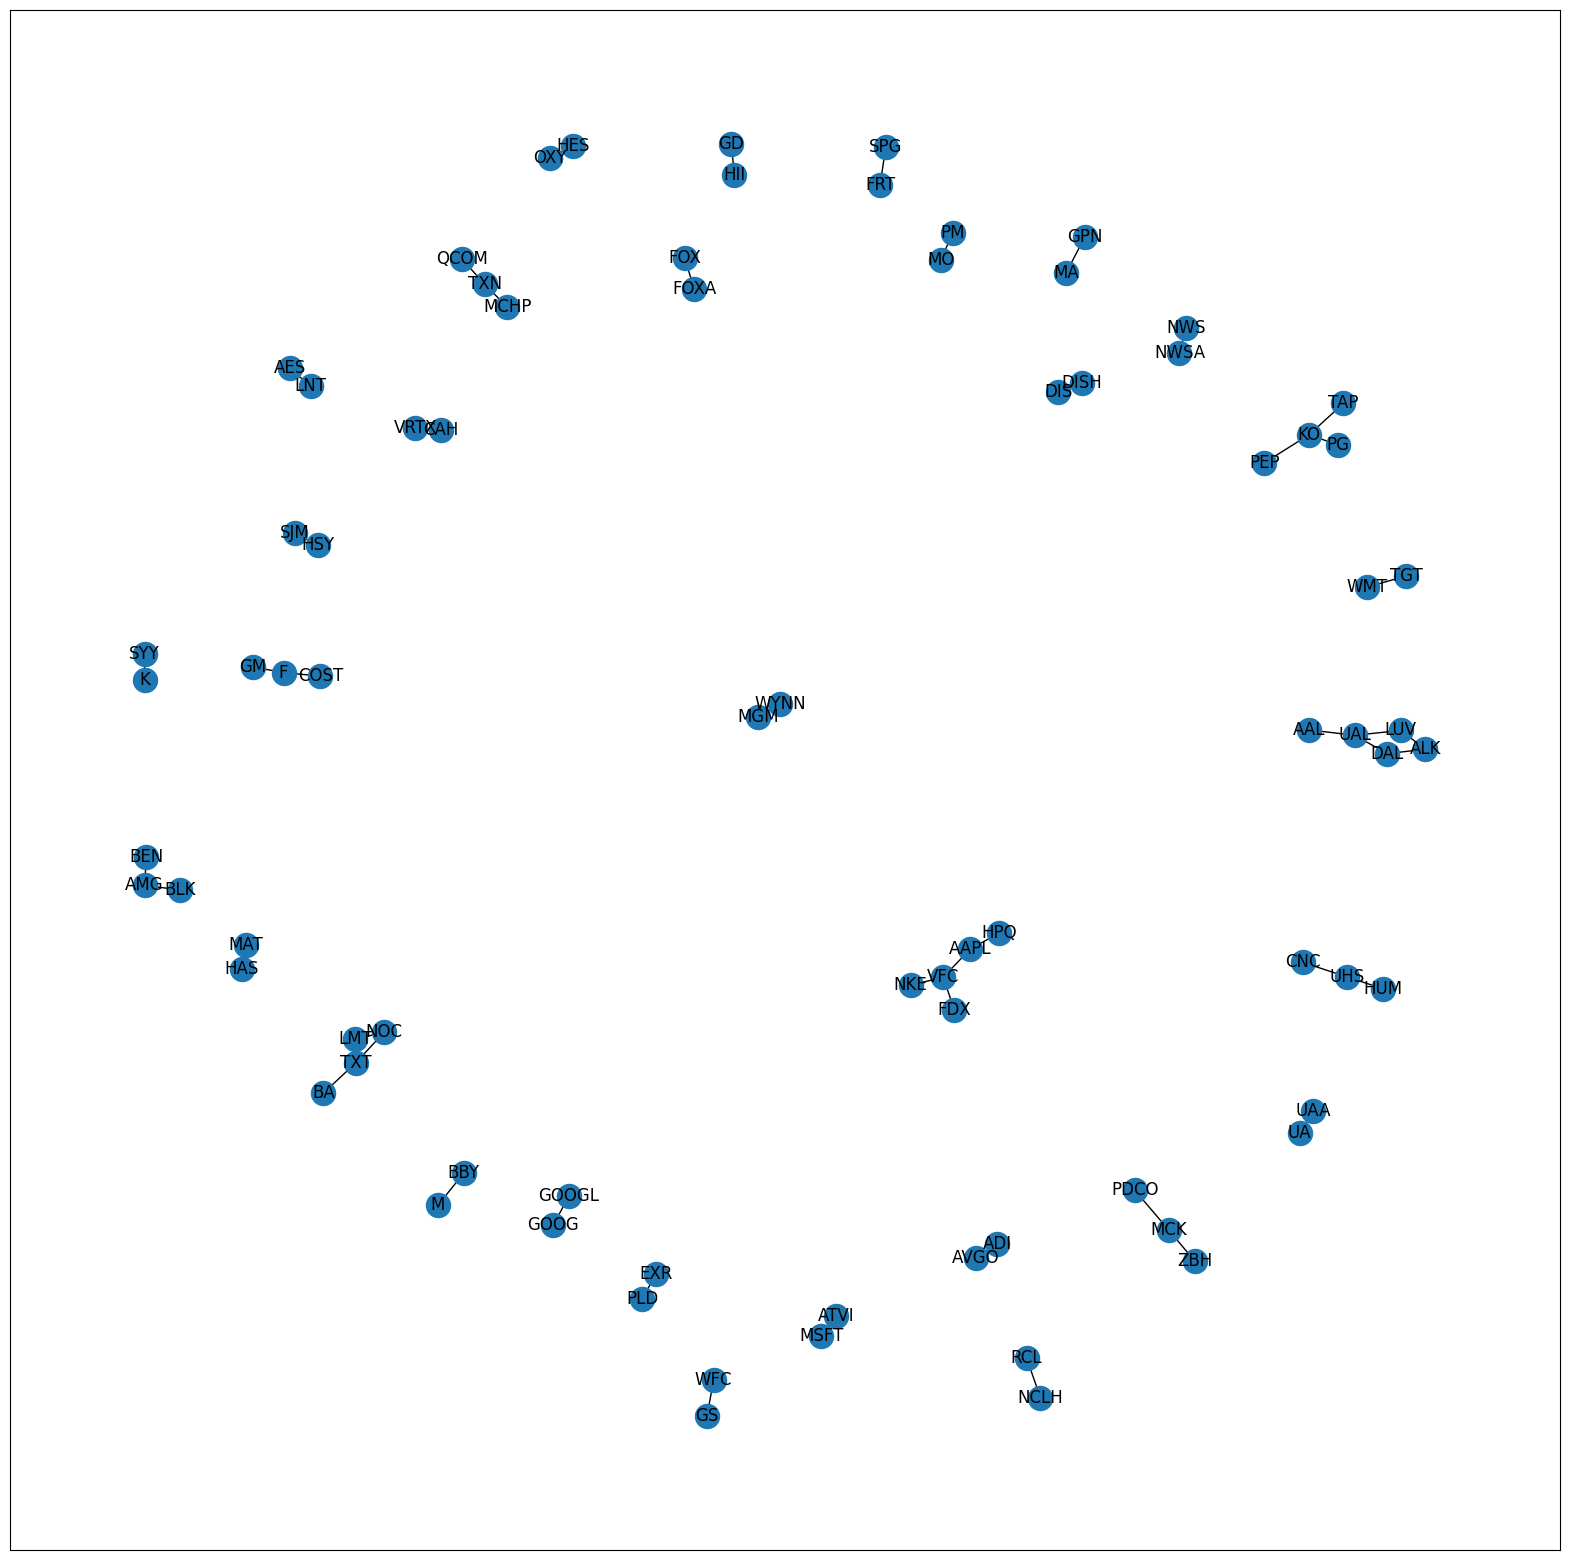

In [11]:
G_of_day = VisualizeGraphDataset(dataset, day=0, full=True)
Describe(G_of_day)

[('AAPL', 5), ('NOC', 3), ('TXT', 3), ('UAL', 3), ('VFC', 3), ('KO', 3), ('AMG', 2), ('LMT', 2), ('OXY', 2), ('GOOG', 2), ('GOOGL', 2), ('DAL', 2), ('TXN', 2), ('MSFT', 2), ('ALK', 2), ('MCK', 2), ('HII', 2), ('UHS', 2), ('LUV', 2), ('RCL', 2), ('F', 2), ('PFE', 2), ('NI', 2), ('FE', 2), ('PNW', 2), ('AMZN', 2), ('DISH', 1), ('DIS', 1), ('NWS', 1), ('NWSA', 1), ('AVGO', 1), ('ADI', 1), ('FRT', 1), ('SPG', 1), ('GPN', 1), ('MA', 1), ('BEN', 1), ('BLK', 1), ('HES', 1), ('SYY', 1), ('K', 1), ('AES', 1), ('LNT', 1), ('CAH', 1), ('VRTX', 1), ('UAA', 1), ('UA', 1), ('WMT', 1), ('TGT', 1), ('SJM', 1), ('HSY', 1), ('AAL', 1), ('HPQ', 1), ('MCHP', 1), ('FOX', 1), ('FOXA', 1), ('ATVI', 1), ('ZBH', 1), ('PDCO', 1), ('NKE', 1), ('FDX', 1), ('GD', 1), ('HUM', 1), ('CNC', 1), ('MAT', 1), ('HAS', 1), ('EXR', 1), ('PLD', 1), ('QCOM', 1), ('BA', 1), ('PM', 1), ('MO', 1), ('NCLH', 1), ('PG', 1), ('BBY', 1), ('M', 1), ('WYNN', 1), ('MGM', 1), ('TAP', 1), ('PEP', 1), ('COST', 1), ('WFC', 1), ('GS', 1), ('

,Degree
count,94.000000
mean,1.361702
std,0.685504
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5.000000


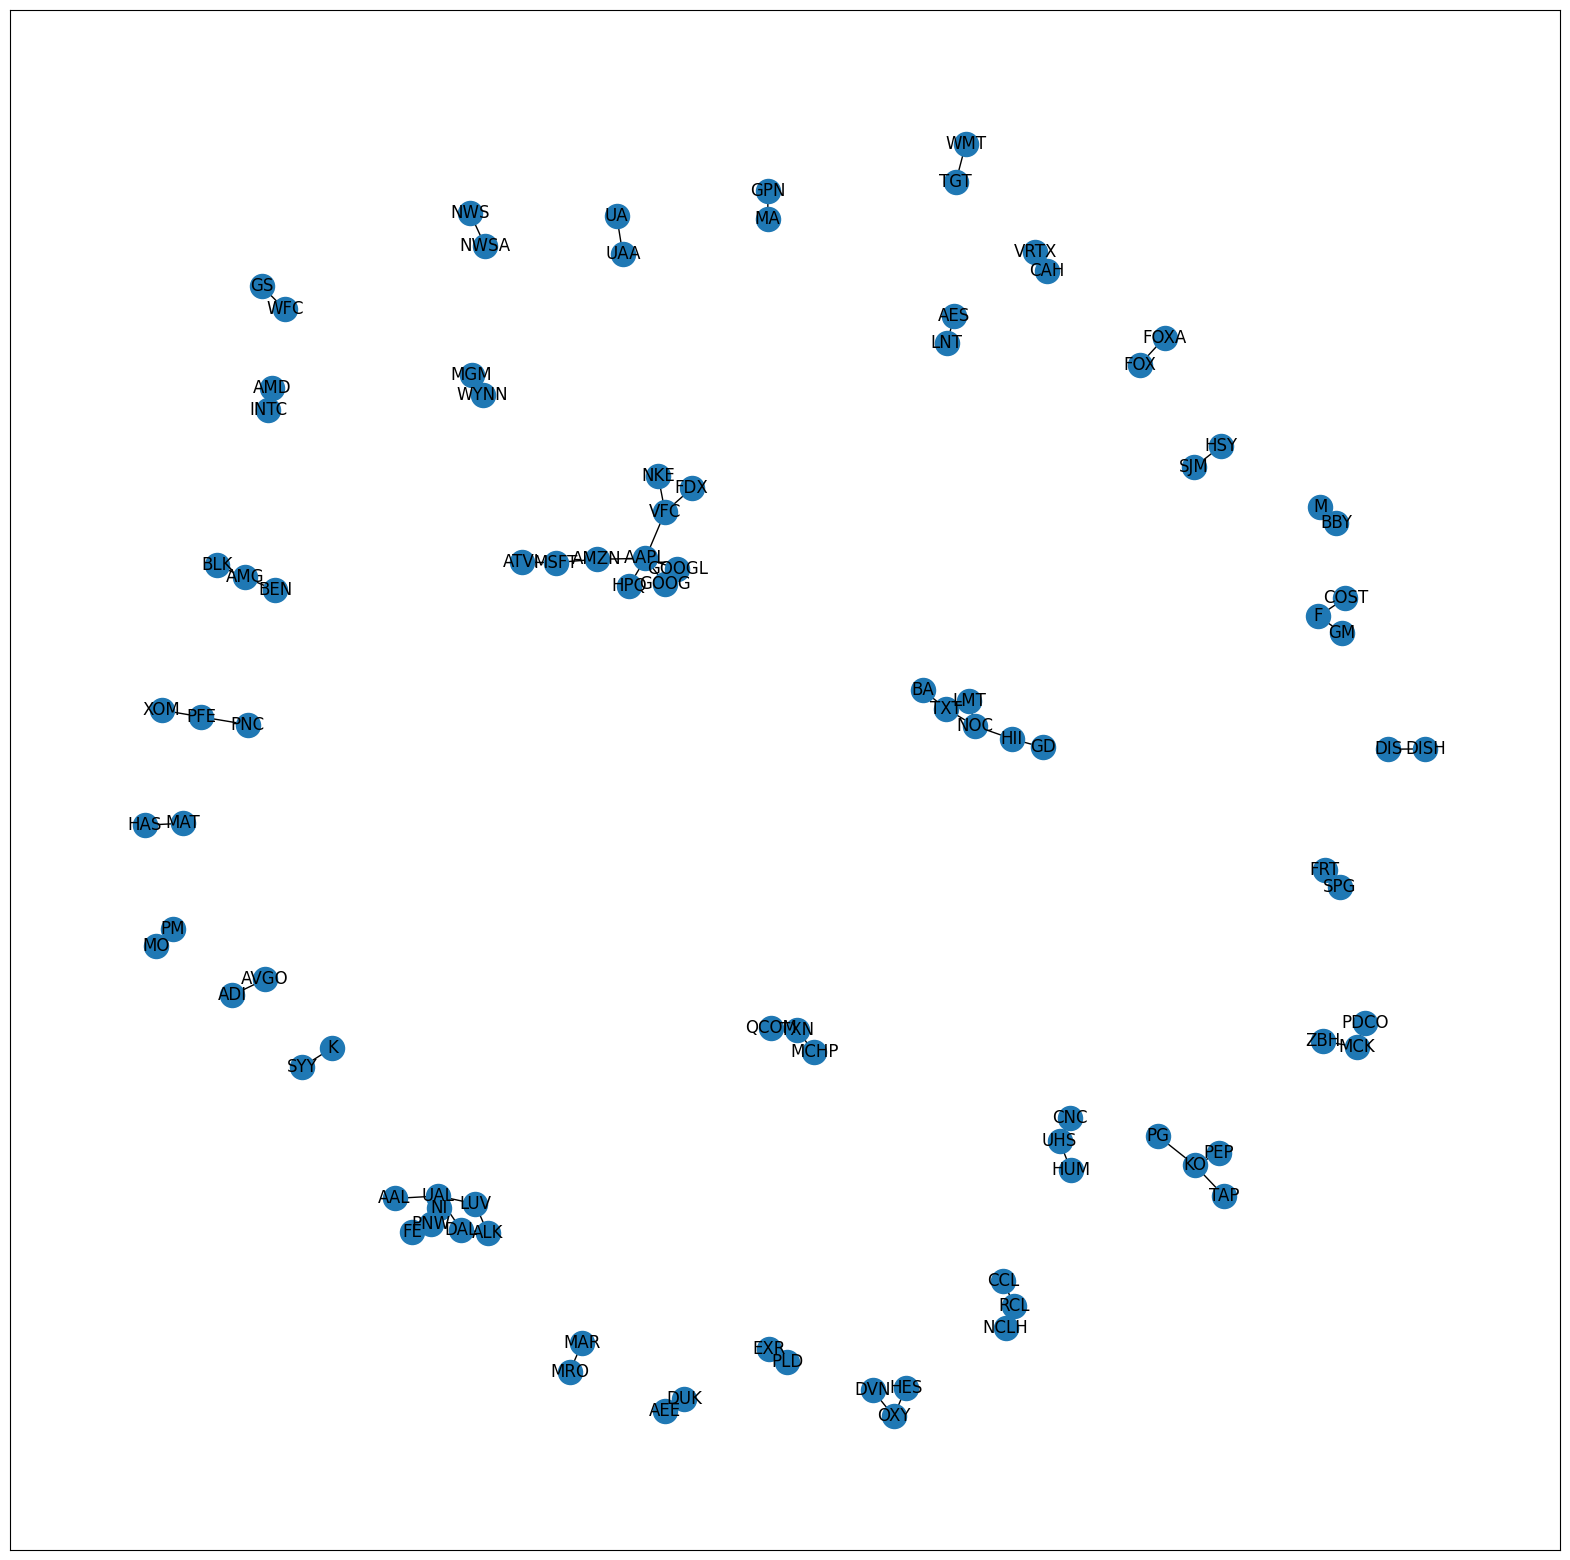

In [12]:
G_of_day = VisualizeGraphDataset(dataset, day=1, full=True)
Describe(G_of_day)

[('AAPL', 9), ('AMZN', 9), ('MSFT', 8), ('LMT', 7), ('CAH', 7), ('NOC', 5), ('AMD', 5), ('NFLX', 5), ('BAC', 5), ('GOOGL', 4), ('WMT', 4), ('KO', 4), ('XOM', 4), ('CVX', 4), ('DAL', 4), ('QCOM', 4), ('VRTX', 4), ('UNH', 4), ('DIS', 3), ('NWSA', 3), ('GOOG', 3), ('FOXA', 3), ('MCK', 3), ('FE', 3), ('A', 3), ('EMR', 3), ('GD', 3), ('NVDA', 3), ('AVGO', 3), ('KR', 3), ('TXT', 3), ('UAL', 3), ('BA', 3), ('AAL', 3), ('ALK', 3), ('VFC', 3), ('FDX', 3), ('WFC', 3), ('PFE', 3), ('CSCO', 3), ('JNJ', 3), ('IBM', 3), ('BK', 3), ('C', 3), ('JPM', 3), ('NWS', 2), ('AMG', 2), ('BLK', 2), ('OXY', 2), ('TGT', 2), ('PG', 2), ('FOX', 2), ('NI', 2), ('PNW', 2), ('INTC', 2), ('AMAT', 2), ('SPG', 2), ('MAR', 2), ('FRT', 2), ('MRO', 2), ('AZO', 2), ('HUM', 2), ('COST', 2), ('HAS', 2), ('TXN', 2), ('RCL', 2), ('LUV', 2), ('NKE', 2), ('HII', 2), ('F', 2), ('UHS', 2), ('DVN', 2), ('CMI', 2), ('MU', 2), ('MS', 2), ('CVS', 2), ('ISRG', 2), ('DISH', 1), ('BEN', 1), ('HES', 1), ('UAA', 1), ('UA', 1), ('PM', 1), ('

,Degree
count,148.000000
mean,2.108108
std,1.548030
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,9.000000


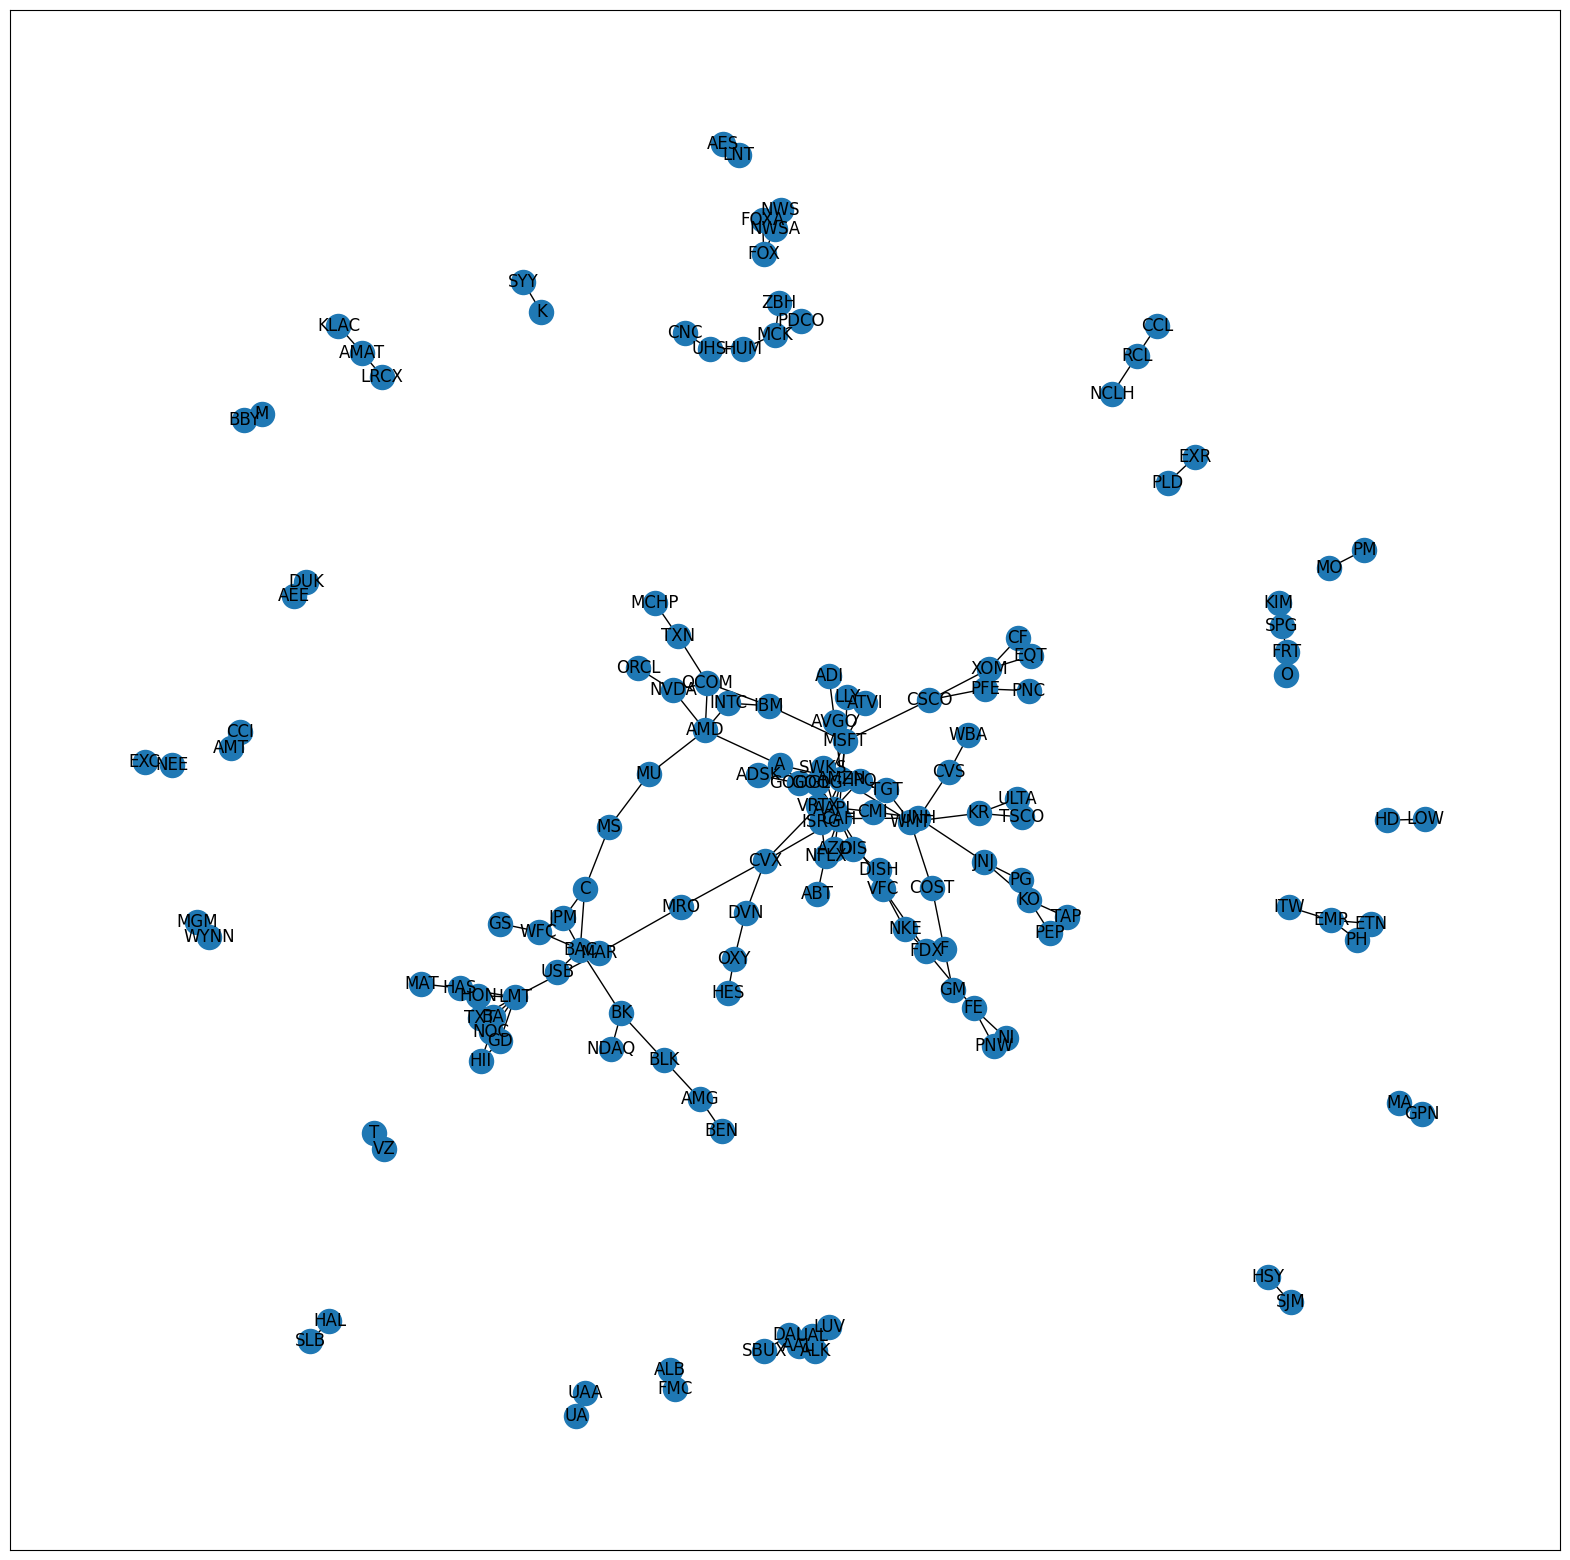

In [13]:
G_of_day = VisualizeGraphDataset(dataset, day=10, full=True)
Describe(G_of_day)

[('MSFT', 49), ('NVDA', 48), ('AAPL', 48), ('AMZN', 46), ('GOOGL', 35), ('WMT', 33), ('CVX', 32), ('NFLX', 28), ('KO', 27), ('TGT', 27), ('BAC', 25), ('XOM', 25), ('AMD', 24), ('IBM', 24), ('JNJ', 23), ('ADBE', 21), ('INTC', 21), ('CSCO', 21), ('PG', 21), ('DIS', 19), ('NKE', 19), ('AXP', 19), ('PFE', 18), ('COST', 17), ('AVGO', 17), ('ORCL', 17), ('UNH', 17), ('AMGN', 17), ('CAT', 16), ('HD', 16), ('DE', 16), ('A', 15), ('JPM', 15), ('BA', 15), ('CAH', 15), ('D', 15), ('QCOM', 15), ('MA', 14), ('PEP', 14), ('DG', 14), ('MRK', 14), ('CRM', 14), ('PNC', 13), ('WBA', 13), ('MCK', 13), ('MCD', 13), ('PYPL', 13), ('AMAT', 13), ('LMT', 12), ('VZ', 12), ('FDX', 12), ('OXY', 12), ('USB', 12), ('MU', 12), ('ABBV', 12), ('GS', 11), ('PXD', 11), ('SBUX', 11), ('T', 11), ('MPC', 11), ('ETR', 11), ('JWN', 11), ('LRCX', 11), ('M', 11), ('V', 10), ('DAL', 10), ('C', 10), ('MAR', 10), ('UPS', 10), ('LLY', 10), ('KHC', 10), ('HOLX', 10), ('GIS', 10), ('CMG', 10), ('GE', 10), ('NEE', 10), ('ADM', 10), 

,Degree
count,371.000000
mean,6.743935
std,7.196973
min,1.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,49.000000


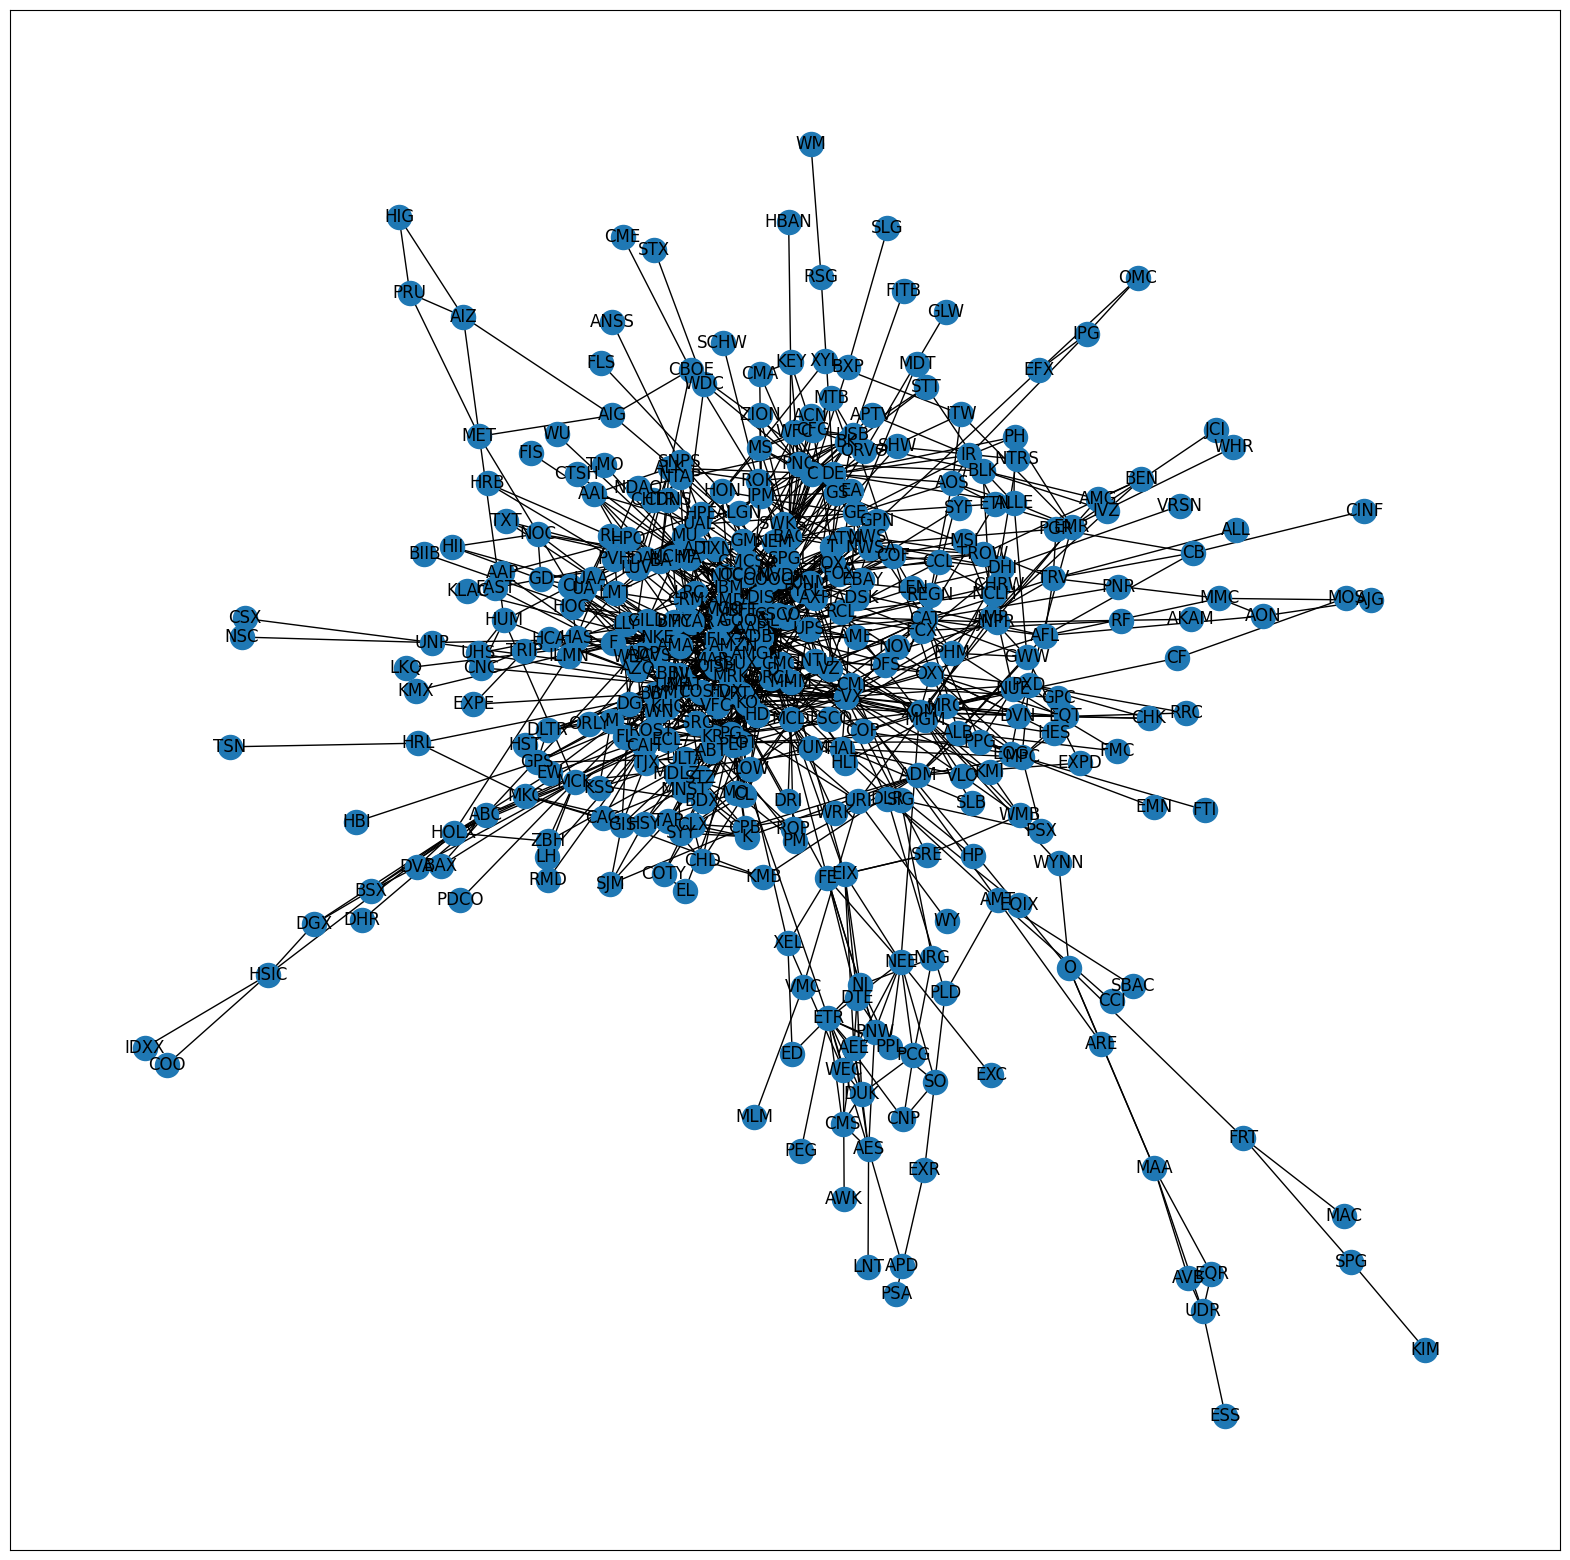

In [45]:
G_of_day = VisualizeGraphDataset(dataset, day=257, full=True)
Describe(G_of_day)


## (Wrong) WrongWeight_NoLookBack_merge/ Node3_Edge1_Normmean_Threshold3.0_WeightedEdgeCounter_merge_True


In [16]:
dataset = MyDataset(root=f'{ERGATFOLDERPATH}data/202209_202310/dynamic/Node6_Edge1_Normmean_Threshold3.0_WeightedEdgeCounter_merge_True/')

[('NVDA', 26), ('AMZN', 24), ('MSFT', 21), ('AAPL', 21), ('WMT', 18), ('GOOGL', 13), ('AMD', 13), ('CVX', 12), ('JNJ', 11), ('BAC', 11), ('A', 10), ('D', 10), ('INTC', 9), ('DIS', 9), ('AVGO', 9), ('CAH', 9), ('BA', 9), ('NFLX', 9), ('HOLX', 9), ('JPM', 8), ('HD', 8), ('LRCX', 8), ('MCK', 8), ('DAL', 7), ('C', 7), ('XOM', 7), ('NKE', 7), ('TGT', 7), ('AMGN', 7), ('CSCO', 7), ('MRK', 7), ('QCOM', 7), ('LMT', 6), ('MAR', 6), ('WFC', 6), ('KO', 6), ('PCAR', 6), ('ORCL', 6), ('OXY', 6), ('CMCSA', 6), ('FDX', 6), ('PG', 6), ('DE', 6), ('LUV', 6), ('WBA', 6), ('GOOG', 5), ('PNC', 5), ('UAL', 5), ('PEP', 5), ('ABC', 5), ('AXP', 5), ('MAT', 5), ('IR', 5), ('AAL', 5), ('MS', 5), ('GS', 5), ('HUM', 5), ('ALK', 5), ('EIX', 5), ('UNH', 5), ('CRM', 5), ('NOC', 4), ('RCL', 4), ('T', 4), ('MDLZ', 4), ('ALLE', 4), ('CHD', 4), ('ETR', 4), ('MAA', 4), ('CLX', 4), ('M', 4), ('MCD', 4), ('PVH', 4), ('DG', 4), ('SYY', 4), ('K', 4), ('UNM', 4), ('VLO', 4), ('LLY', 4), ('PFE', 4), ('ADBE', 4), ('CMG', 4), ('

,Degree
count,280.000000
mean,3.435714
std,3.474868
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,26.000000


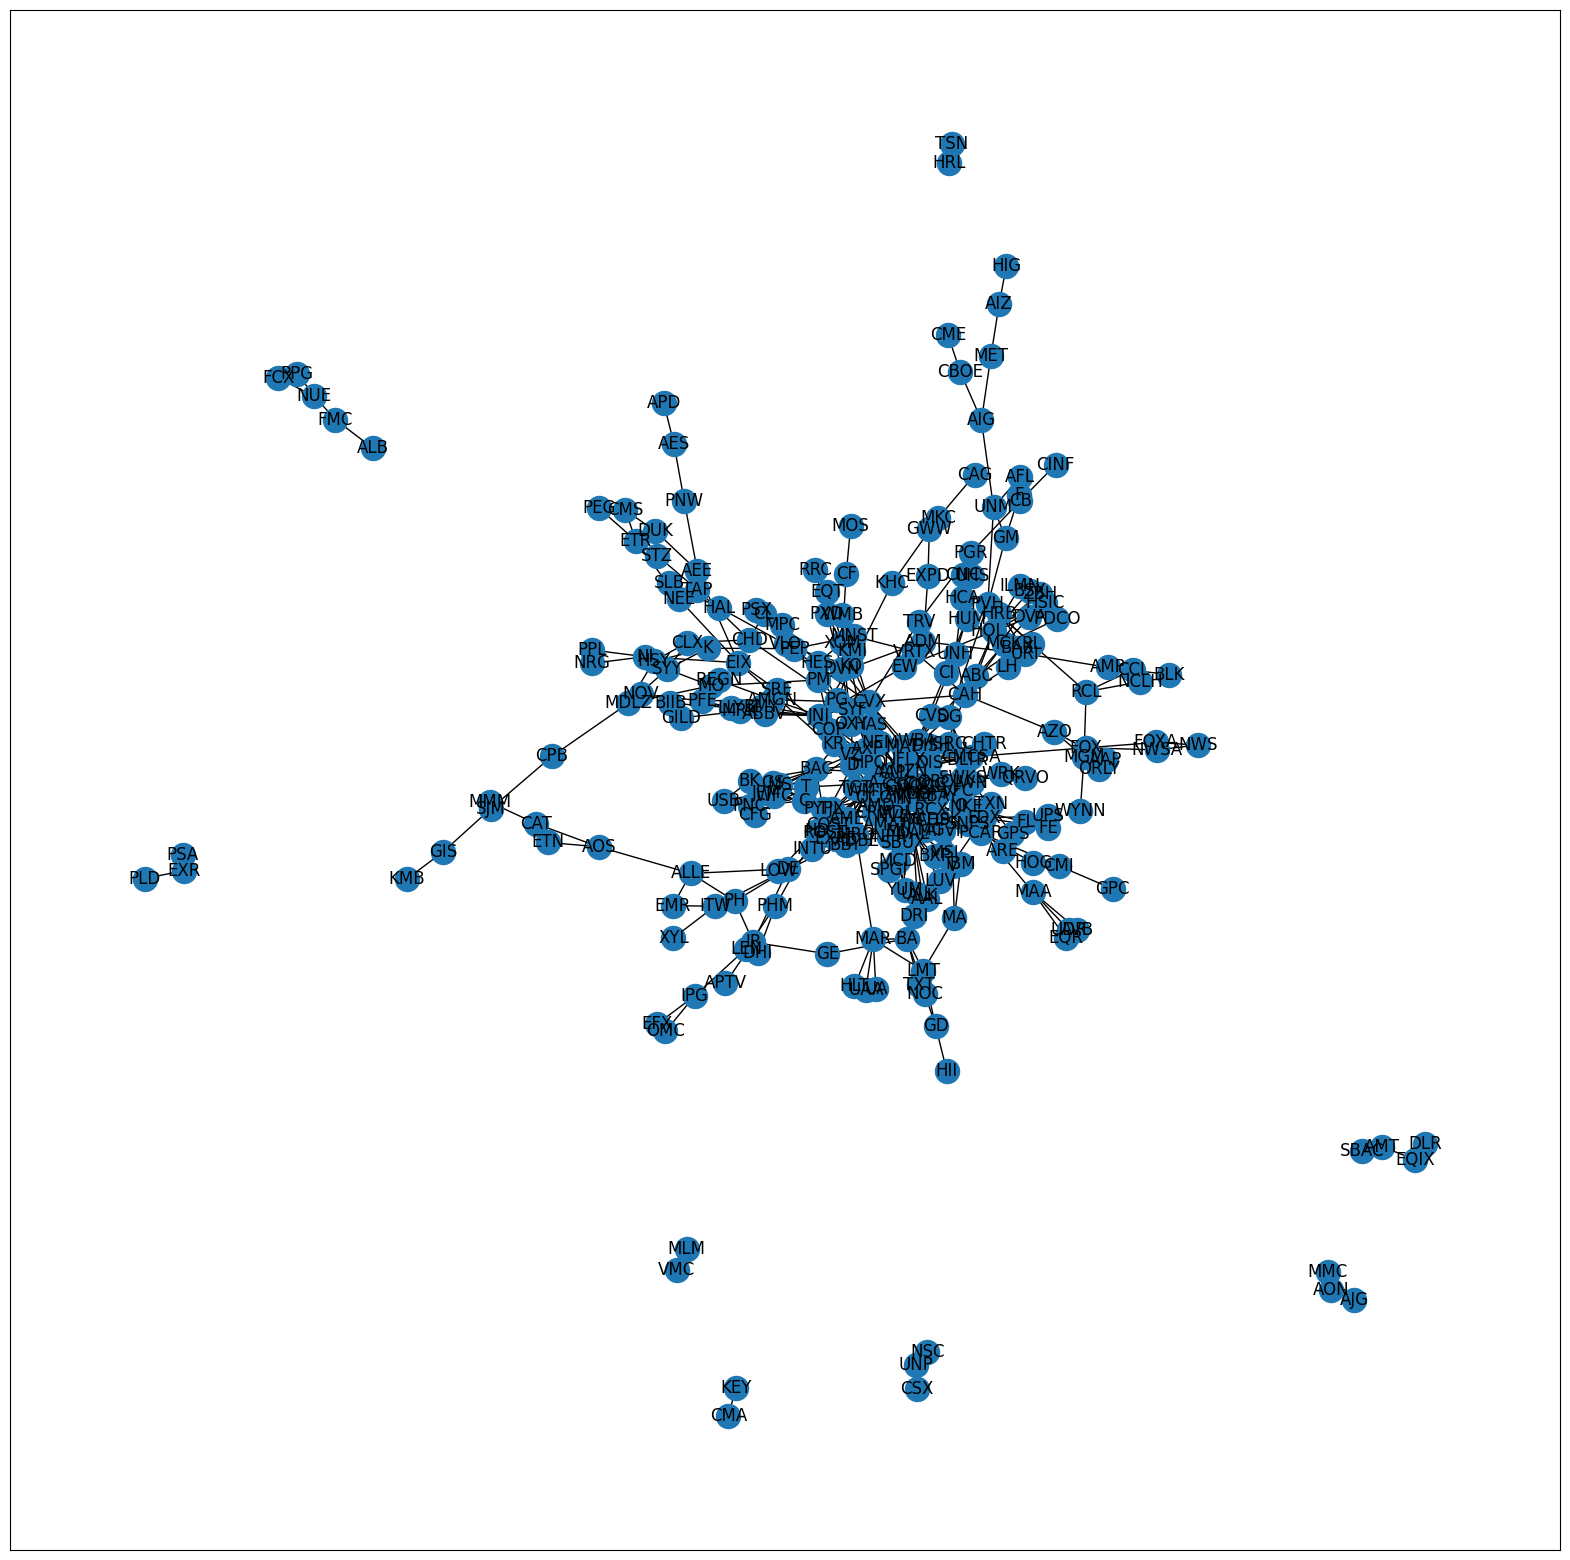

In [17]:
G_of_day = VisualizeGraphDataset(dataset, day=257, full=True)
Describe(G_of_day)

## Node3_Edge1_Normmean_Threshold0.1_WeightedEdgeCorrelation_thgnn_True

* Node features = 3
* Edge features = 1
* Mean normalize node features and edge weights. 
* Threshold = 0.1, 如果两个公司在过去N天内的corr大于threshold，则给这两个公司node建一个edge， corr由计算方法参考THGNN文章，即取两个公司的quantitative features分别计算PCC然后再取均值，这里N=13
* WeightedEdge = Correlation, edge weight是两个公司过去N天的corr（对每天的图中所有edge weight 做normalize）
* build_edges = thgnn， 每天的图单独计算， 不与之前的图叠加
* forRNN = True: Node embedding should be (LOOKBACK_WINDOW, node_features)

以corr作为建立连接的判断条件会使图的连通度非常高，每天的图中边的


In [4]:
dataset = MyDataset(root=f'{ERGATFOLDERPATH}data/202209_202310/dynamic/Node3_Edge1_Normmean_Threshold0.1_WeightedEdgeCorrelation_thgnn_True_2/')

In [5]:
dataset[0].y

tensor([[-0.0124],
        [-0.0318],
        [-0.0299],
        [ 0.0183],
        [-0.0277],
        [-0.0551],
        [-0.0306],
        [-0.0467],
        [-0.0647],
        [-0.0270],
        [-0.0574],
        [-0.0155],
        [-0.0212],
        [-0.0262],
        [-0.0409],
        [-0.0095],
        [-0.0405],
        [-0.0152],
        [-0.0160],
        [-0.0166],
        [-0.0116],
        [ 0.0008],
        [-0.0166],
        [-0.0203],
        [-0.0185],
        [-0.0177],
        [-0.0086],
        [-0.0143],
        [-0.0294],
        [-0.0292],
        [-0.0189],
        [-0.0338],
        [-0.0211],
        [-0.0158],
        [-0.0221],
        [-0.0094],
        [-0.0180],
        [-0.0338],
        [-0.0398],
        [-0.0088],
        [-0.0240],
        [-0.0124],
        [-0.0177],
        [-0.0203],
        [-0.0416],
        [-0.0175],
        [ 0.0108],
        [-0.0311],
        [-0.0210],
        [-0.0392],
        [ 0.0003],
        [-0.0290],
        [-0.

[('ALLE', 248), ('MDT', 247), ('ARE', 244), ('ROST', 242), ('BK', 241), ('C', 241), ('APTV', 239), ('IVZ', 239), ('IQV', 238), ('APH', 237), ('MRK', 237), ('GPN', 237), ('JCI', 236), ('UA', 236), ('NVDA', 236), ('MAR', 236), ('PX', 235), ('AOS', 235), ('CSCO', 234), ('CCL', 234), ('STZ', 234), ('AMP', 234), ('HPE', 234), ('GOOG', 233), ('DTE', 233), ('RHI', 233), ('GT', 233), ('PNW', 233), ('WU', 232), ('COST', 232), ('FTI', 232), ('PRU', 232), ('A', 232), ('MMM', 232), ('REGN', 231), ('MAS', 231), ('CFG', 231), ('COP', 231), ('BHF', 231), ('AMD', 231), ('IFF', 231), ('SBUX', 231), ('MCO', 230), ('CI', 230), ('TRV', 230), ('BIIB', 230), ('COTY', 230), ('FAST', 230), ('HST', 230), ('CMG', 230), ('RSG', 230), ('ADI', 230), ('EXPE', 230), ('PEP', 230), ('ADP', 229), ('BLK', 229), ('CNP', 229), ('SPG', 229), ('KHC', 229), ('AIZ', 229), ('FTV', 229), ('AVB', 228), ('BDX', 228), ('AVY', 228), ('APD', 228), ('PCG', 228), ('HSY', 228), ('MOS', 228), ('HES', 228), ('PEG', 228), ('JNPR', 228), (

,Degree
count,431.000000
mean,216.988399
std,10.811379
min,184.000000
25%,210.000000
50%,217.000000
75%,225.000000
max,248.000000


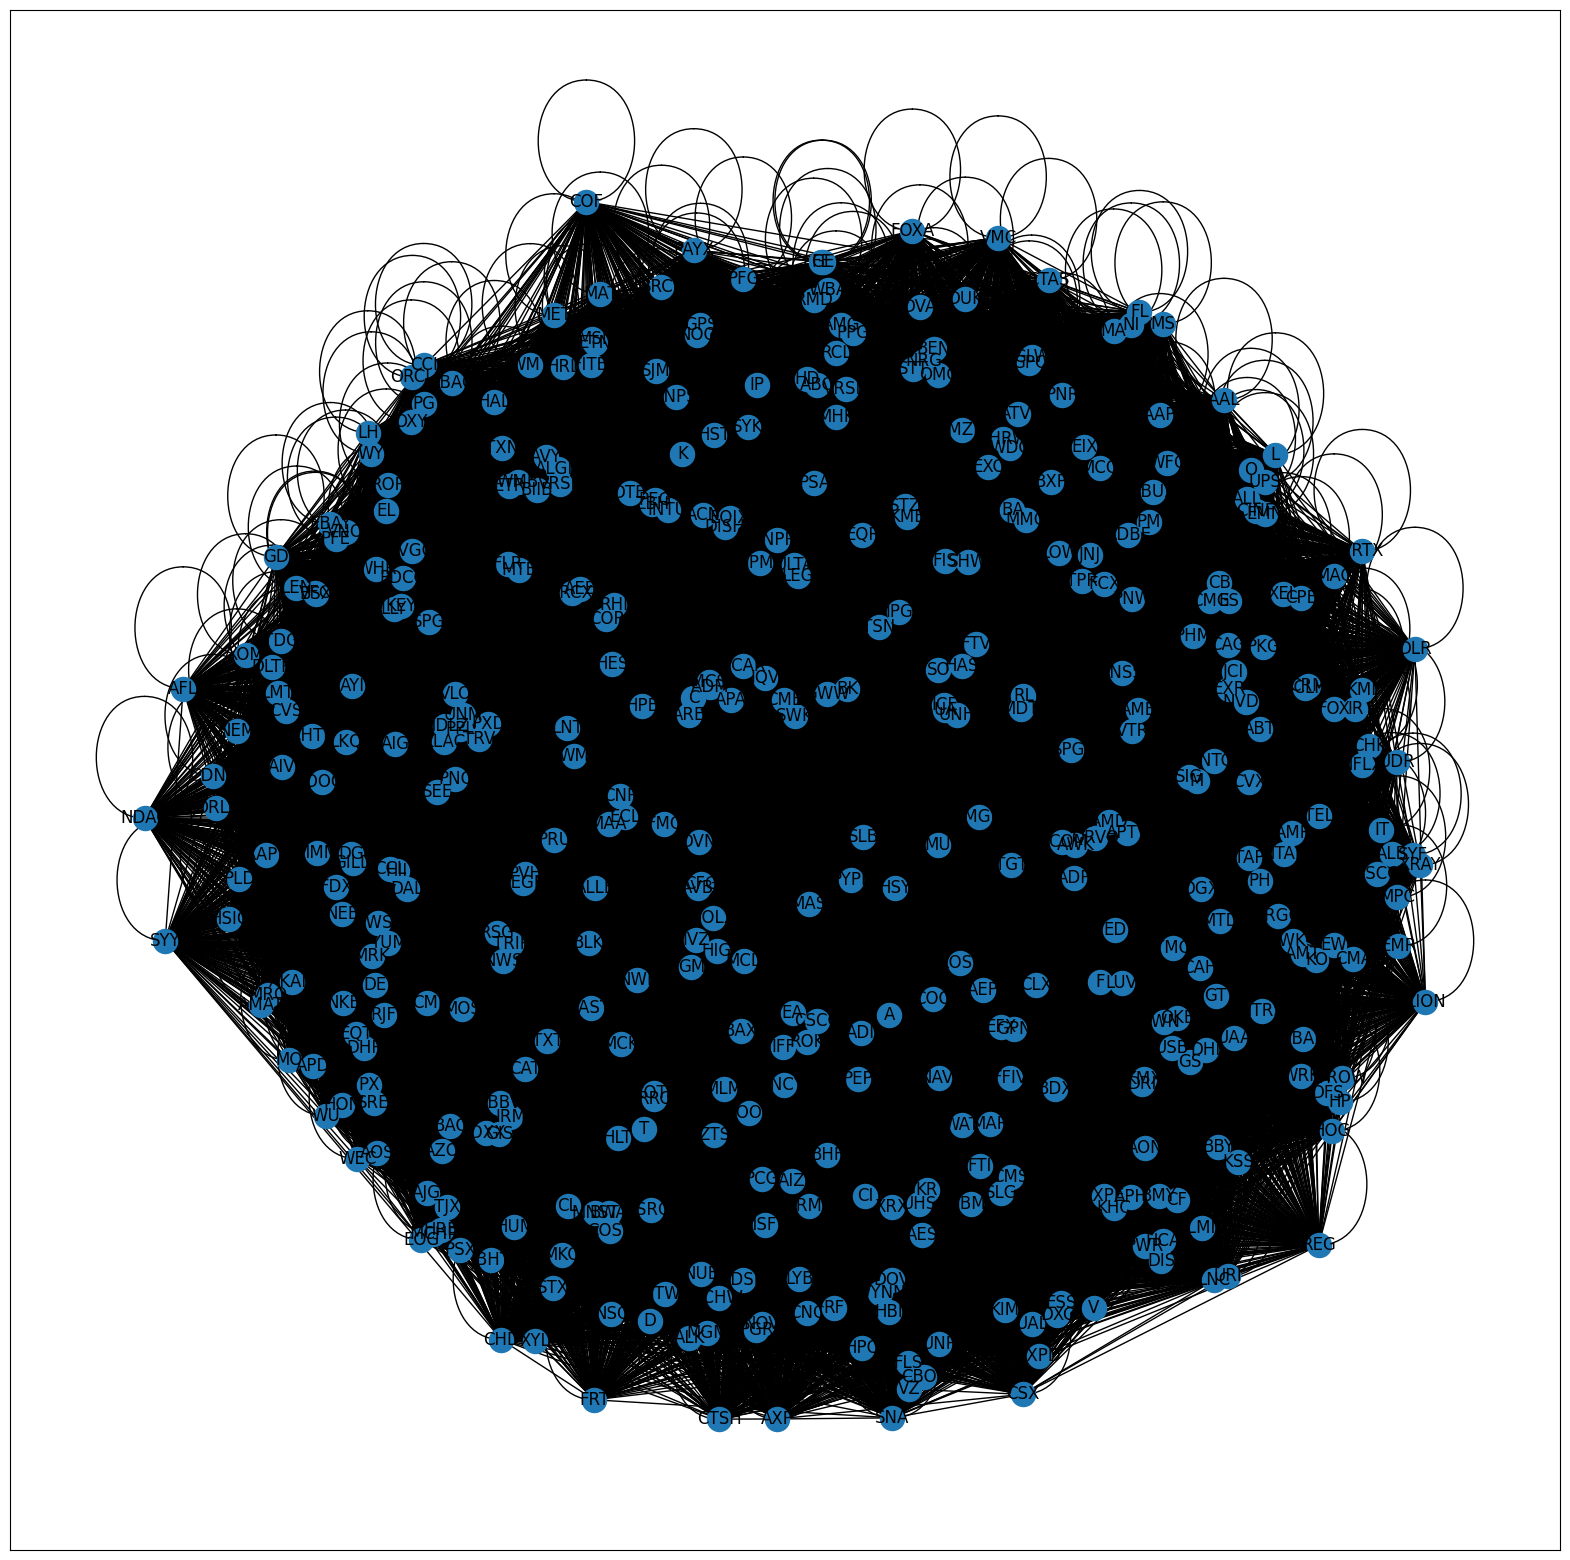

In [7]:
G_of_day = VisualizeGraphDataset(dataset, day=1, full=True)
Describe(G_of_day)

##  Node3_Edge1_Normmean_Threshold1.0_WeightedEdgeCounter_merge_True
* Node features = 3
* Edge features = 1
* Mean normalize node features and edge weights. 
* Threshold = 1.0, 如果两个公司在同一天内同时出现在一篇新闻中的次数大于threshold，则给这两个公司node建一个edge
* WeightedEdge = Counter, edge weight是两个公司共同出现的次数（对每天的图中所有edge weight 做normalize）
* build_edges = merge， 每天的图会叠加在之前的图上，构造出一个historical graph
* forRNN = True: Node embedding should be (LOOKBACK_WINDOW, node_features)

In [8]:
dataset = MyDataset(root=f'{ERGATFOLDERPATH}data/202209_202310/dynamic/Node3_Edge1_Normmean_Threshold1.0_WeightedEdgeCounter_merge_True/')

[('NVDA', 25), ('AAPL', 24), ('MSFT', 22), ('PEP', 20), ('AMZN', 20), ('XOM', 19), ('GOOGL', 19), ('CVX', 17), ('KO', 17), ('JPM', 16), ('TGT', 15), ('AMD', 15), ('CAT', 13), ('BAC', 13), ('COST', 13), ('WMT', 12), ('ORCL', 12), ('DIS', 12), ('DAL', 12), ('WBA', 11), ('NFLX', 11), ('JNJ', 11), ('LMT', 10), ('INTC', 10), ('MCD', 10), ('GS', 9), ('ABBV', 9), ('NEE', 9), ('HD', 9), ('GD', 9), ('PG', 9), ('UNH', 9), ('IBM', 9), ('GM', 8), ('NOC', 8), ('F', 8), ('ADBE', 8), ('CMCSA', 8), ('WFC', 8), ('NKE', 8), ('AXP', 8), ('AVGO', 8), ('MSI', 7), ('CRM', 7), ('A', 7), ('PXD', 7), ('GOOG', 7), ('BA', 7), ('DG', 7), ('ABT', 7), ('LOW', 6), ('VZ', 6), ('PNC', 6), ('UAL', 6), ('MA', 6), ('QRVO', 6), ('STZ', 6), ('C', 6), ('BMY', 6), ('TJX', 6), ('BLK', 6), ('KMX', 6), ('MRK', 6), ('ROST', 5), ('RCL', 5), ('ATVI', 5), ('LUV', 5), ('ECL', 5), ('MAR', 5), ('DHR', 5), ('MU', 5), ('UPS', 5), ('DVA', 5), ('QCOM', 5), ('MMM', 5), ('EMR', 5), ('NWSA', 4), ('ETN', 4), ('IR', 4), ('FOXA', 4), ('SPG', 4)

,Degree
count,283.000000
mean,4.070671
std,4.239541
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,25.000000


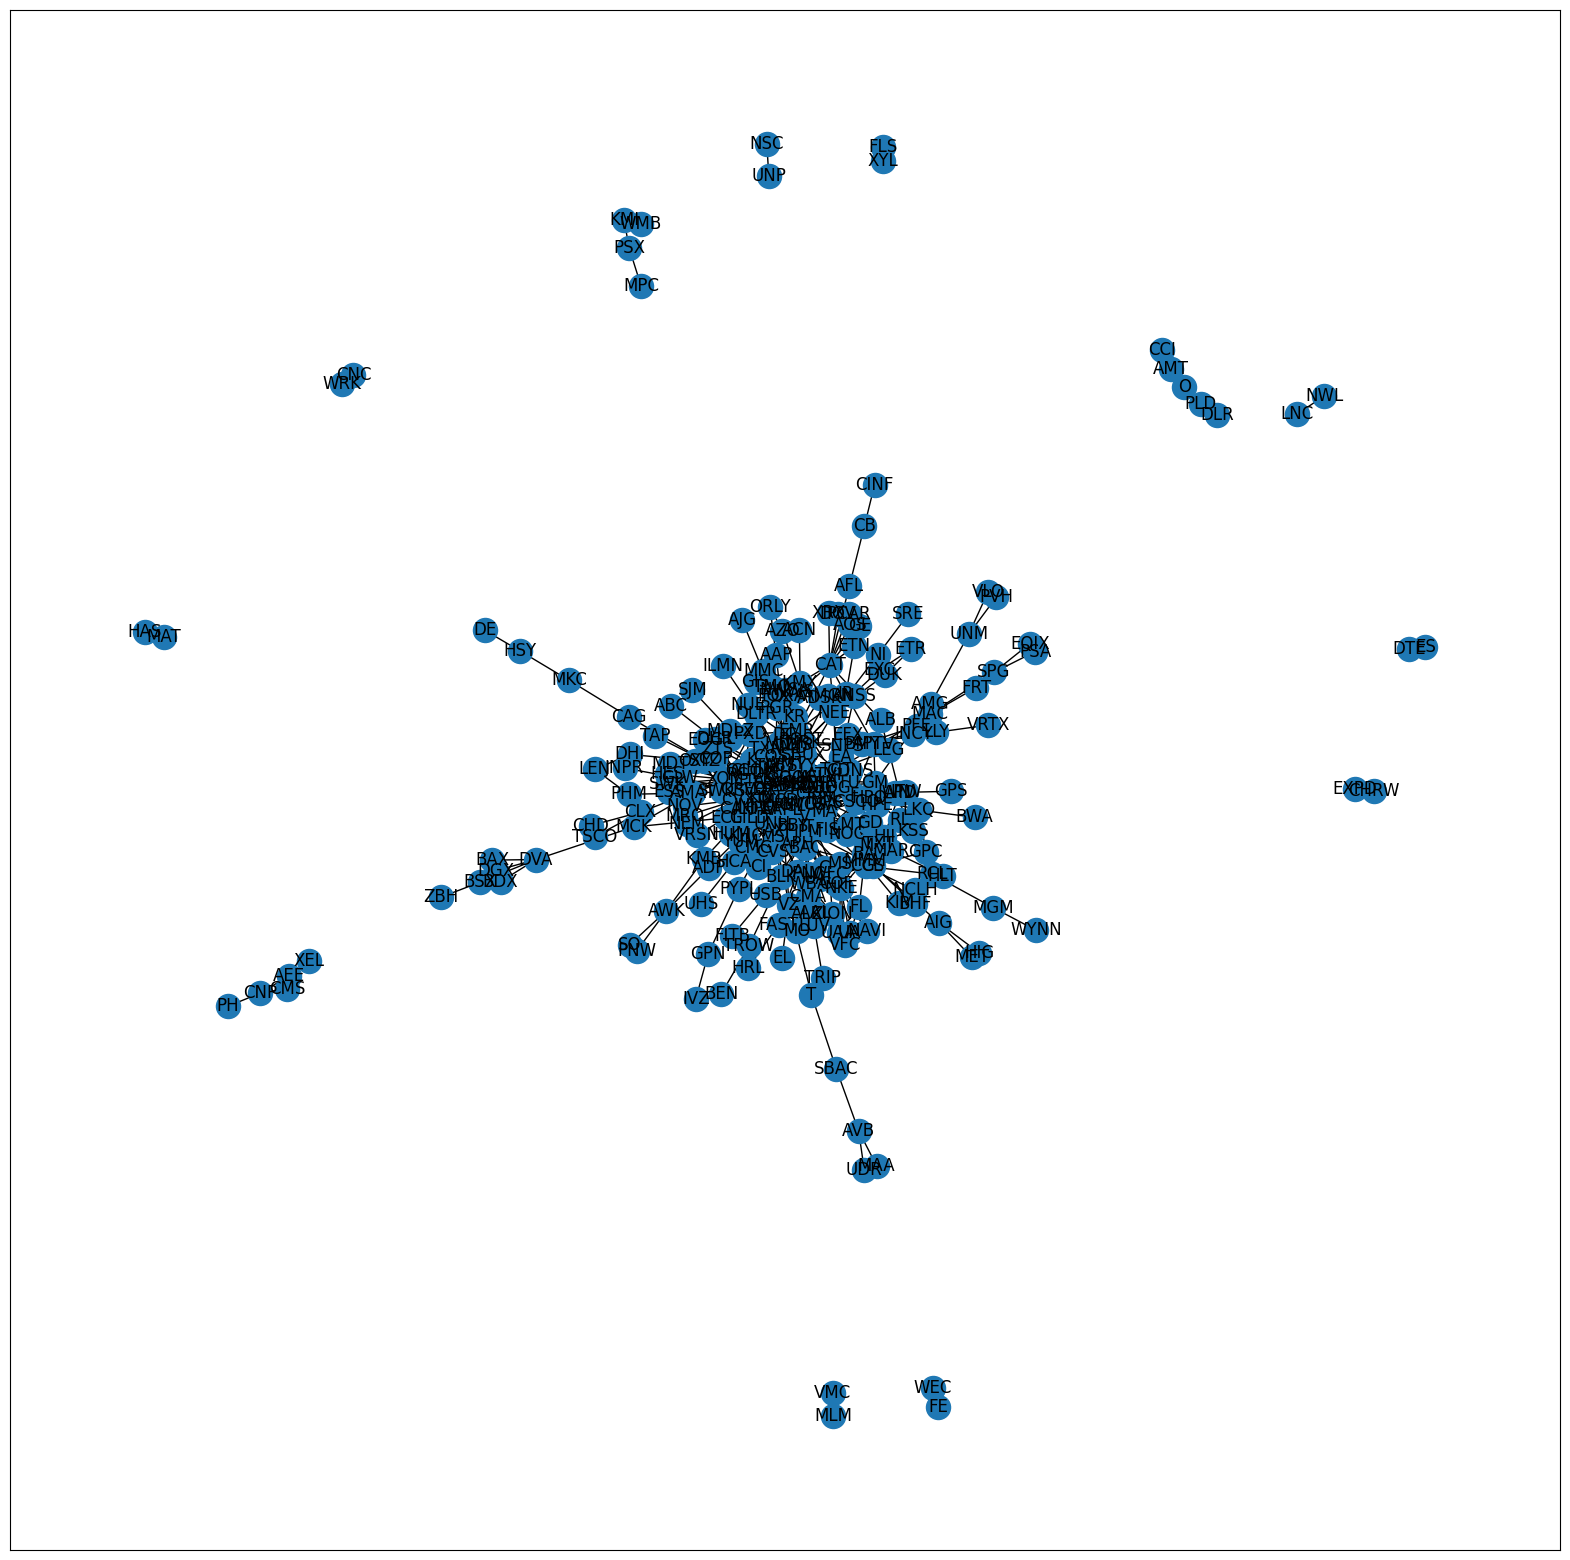

In [39]:
G_of_day = VisualizeGraphDataset(dataset, day=256, full=True)
Describe(G_of_day)

In [14]:
G_of_day.adj['MSFT']

AtlasView({'ATVI': {'Weight': 1.202679848963758}, 'VMC': {'Weight': -0.5420528896738064}, 'EA': {'Weight': -0.5420528896738064}, 'GOOGL': {'Weight': -0.5420528896738064}})

In [38]:
connected_nodes = torch.tensor(np.array(list(set(np.array(dataset[36].edge_index[0])))))
dataset[36].subgraph(connected_nodes)

Data(x=[282, 13, 3], edge_index=[2, 1098], edge_attr=[1098, 1], y=[282, 1])

# scratch

In [6]:
import torch_geometric as pyg

In [38]:
gat = pyg.nn.GATConv(64, 256, 4, edge_dim=1)

In [43]:
gat.state_dict()

OrderedDict([('att_src',
              tensor([[[-0.0986,  0.1334,  0.0371,  ..., -0.1302,  0.0576, -0.1334],
                       [-0.0885,  0.1358, -0.0403,  ..., -0.0795, -0.0111, -0.1093],
                       [-0.0815, -0.0579,  0.0551,  ..., -0.1154, -0.0862,  0.1385],
                       [-0.1183,  0.0780, -0.1472,  ..., -0.0553, -0.0556, -0.0087]]])),
             ('att_dst',
              tensor([[[ 0.0732,  0.0234,  0.0715,  ..., -0.1304, -0.0733,  0.0423],
                       [ 0.1164,  0.0899,  0.1145,  ..., -0.0760,  0.0605, -0.0174],
                       [-0.0147, -0.0192, -0.1280,  ...,  0.1205, -0.0012, -0.0198],
                       [ 0.0189,  0.0481,  0.0785,  ..., -0.0679,  0.0431,  0.0310]]])),
             ('att_edge',
              tensor([[[-0.0752, -0.1488, -0.0747,  ...,  0.0205,  0.1453,  0.1404],
                       [ 0.1416,  0.1098,  0.0136,  ...,  0.1103,  0.1495, -0.0884],
                       [ 0.0102,  0.0300,  0.1017,  ..., -0.1217, 

In [47]:
def initGATConv(gat, glolot_initialization="normal"):
    """
    Initialize the GATConv layer using Glorot Initialization
    """

    if glolot_initialization=='normal':
        torch.nn.init.xavier_normal_(gat.att_src, gain=1)
        torch.nn.init.xavier_normal_(gat.att_dst, gain=1)
        torch.nn.init.xavier_normal_(gat.att_edge, gain=1)
        torch.nn.init.xavier_normal_(gat.lin_src.weight, gain=1)
        torch.nn.init.xavier_normal_(gat.lin_dst.weight, gain=1)
        torch.nn.init.xavier_normal_(gat.lin_edge.weight, gain=1)
    elif glolot_initialization=='uniform':
        torch.nn.init.xavier_uniform_(gat.att_src, gain=1)
        torch.nn.init.xavier_uniform_(gat.att_dst, gain=1)
        torch.nn.init.xavier_uniform_(gat.att_edge, gain=1)
        torch.nn.init.xavier_uniform_(gat.lin_src.weight, gain=1)
        torch.nn.init.xavier_uniform_(gat.lin_dst.weight, gain=1)
        torch.nn.init.xavier_uniform_(gat.lin_edge.weight, gain=1)
    else:
        raise KeyError(glolot_initialization)
    return gat

In [54]:
gat = initGATConv(gat, glolot_initialization='normal')

In [55]:
gat.state_dict()

OrderedDict([('att_src',
              tensor([[[ 0.0149,  0.0369,  0.0889,  ..., -0.0778,  0.0090,  0.0458],
                       [-0.0253,  0.0828, -0.0044,  ..., -0.0067,  0.0008,  0.0413],
                       [ 0.0442,  0.0210, -0.0258,  ..., -0.0089, -0.0049, -0.0282],
                       [ 0.0044, -0.0114, -0.0659,  ...,  0.0619, -0.0038,  0.0117]]])),
             ('att_dst',
              tensor([[[-0.0469,  0.0755, -0.0179,  ..., -0.0234,  0.0667,  0.0242],
                       [ 0.0199, -0.0004, -0.1040,  ..., -0.0122, -0.0312,  0.0196],
                       [-0.0469,  0.0092, -0.0245,  ...,  0.0152, -0.0021, -0.0882],
                       [-0.0341, -0.0171,  0.0404,  ..., -0.0364,  0.0236,  0.0032]]])),
             ('att_edge',
              tensor([[[-0.0065,  0.0050, -0.0327,  ...,  0.0141,  0.0391, -0.0203],
                       [-0.0272, -0.0180,  0.0856,  ...,  0.0177,  0.0110,  0.0567],
                       [-0.0137, -0.0409, -0.0011,  ...,  0.0467, 